# Truth, teacher, and student: SFT, on-policy distillation, and RL

Start with one fixed input $x$.  The object we ultimately care about is an
oracle distribution $p^*(y\mid x)$; a deterministic ground-truth answer
$f^*(x)$ is the special case where this distribution is a point mass.  The
teacher $q_T(y\mid x)$ and current student $p_\theta(y\mid x)$ can each cover,
omit, reweight, or translate different modes of that truth.

> Given $p^*$, an imperfect teacher $q_T$, a current student $p_\theta$, and a
> finite feedback budget, which update moves the student toward the truth—and
> when does its information source make that impossible?

The main benchmark below uses a decaying $n$-mode truth and independently
varies teacher coverage, student initialization, and modal translation.  It
separates four questions that are otherwise easy to conflate:

1. **target bias:** does the method copy (q_T) or optimize truth-derived
   reward?
2. **projection/capacity:** can the student family represent all modes?
3. **exposure:** are useful modes present in teacher data or current student
   samples?
4. **estimation:** how much useful update signal appears at a finite budget?

We first verify the tiny shared operators against Prime-RL.  Later sections
isolate capacity-limited KL geometry, shifted support, student-only recovery
states, curriculum, and forgetting.  The sparse top-k section is an
implementation-specific sidebar, not the conceptual starting point.

In [1]:
from __future__ import annotations

import hashlib
import os
import subprocess
import sys
from dataclasses import asdict
from pathlib import Path

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

HERE = Path.cwd().resolve()
if not (HERE / "toy_methods.py").exists():
    matches = list(HERE.rglob("examples/opd_theory_toys/toy_methods.py"))
    if len(matches) != 1:
        raise RuntimeError("Run from the notebook directory or the Prime-RL checkout.")
    HERE = matches[0].parent
REPO = HERE.parents[1]
for path in (
    REPO,
    REPO / "src",
    REPO / "packages" / "prime-rl-configs" / "src",
):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

torch.set_default_dtype(torch.float64)
torch.set_num_threads(min(4, os.cpu_count() or 1))
pd.set_option("display.precision", 5)

PASTEL = {
    "ink": "#34495E",
    "muted": "#98A1B2",
    "blue": "#79A9DC",
    "mint": "#79C7A3",
    "sage": "#A8C982",
    "apricot": "#F1B56C",
    "coral": "#E8898F",
    "lavender": "#B59AD8",
    "teal": "#69B8B2",
    "rose": "#D97887",
    "paper": "#F7F8FC",
    "panel": "#FFFFFF",
    "grid": "#E5E8F0",
}
PASTEL_RISK_CMAP = LinearSegmentedColormap.from_list(
    "pastel_risk",
    ("#DDF2E5", "#F7E3A3", "#E98A91"),
)
plt.rcParams.update(
    {
        "figure.figsize": (10.5, 5.6),
        "figure.dpi": 120,
        "figure.facecolor": PASTEL["paper"],
        "figure.titlesize": 19,
        "figure.titleweight": "bold",
        "axes.facecolor": PASTEL["panel"],
        "axes.edgecolor": "#D6DAE5",
        "axes.labelcolor": PASTEL["ink"],
        "axes.labelsize": 13,
        "axes.titlecolor": PASTEL["ink"],
        "axes.titlesize": 15,
        "axes.titlelocation": "left",
        "axes.titlepad": 11,
        "axes.titleweight": "bold",
        "axes.prop_cycle": cycler(
            color=(
                PASTEL["blue"],
                PASTEL["apricot"],
                PASTEL["mint"],
                PASTEL["coral"],
                PASTEL["lavender"],
                PASTEL["teal"],
            )
        ),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "grid.color": PASTEL["grid"],
        "grid.alpha": 0.8,
        "grid.linewidth": 0.8,
        "font.size": 12,
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "dejavusans",
        "text.color": PASTEL["ink"],
        "xtick.color": "#596579",
        "xtick.labelsize": 11,
        "ytick.color": "#596579",
        "ytick.labelsize": 11,
        "lines.linewidth": 2.5,
        "lines.markersize": 7,
        "legend.facecolor": PASTEL["panel"],
        "legend.edgecolor": "#DDE1EA",
        "legend.framealpha": 0.95,
        "legend.fontsize": 10,
    }
)

from examples.opd_theory_toys import truth_mixture_experiments as truth_mix
from examples.opd_theory_toys import truth_reward_experiments as truth_reward
from examples.opd_theory_toys import truth_sampling_experiments as truth_sampling
from examples.opd_theory_toys.mixture_experiments import (
    LandscapeConfig,
    asymmetric_teacher,
    entropy_phase_sweep,
    run_asymmetric_study,
)
from examples.opd_theory_toys.prime_loss_checks import run_checks
from examples.opd_theory_toys.retention_experiments import (
    compact_retention_rows,
    run_retention_study,
)
from examples.opd_theory_toys.shift_support_experiments import (
    ShiftConfig,
    compact_update_rows,
    run_shift_sweep,
)
from examples.opd_theory_toys.target_curriculum_experiments import (
    RunConfig,
    make_target_problem,
    run_scale_comparison,
)
from examples.opd_theory_toys.topk_experiments import (
    compact_comparison_records,
    ranked_mode_k_sweep,
    representative_boundary_rows,
    teacher_match_k_sweep,
)
from examples.opd_theory_toys.toy_methods import (
    opd_rkl_population_loss,
    rl_population_loss,
    sft_population_loss,
)
from examples.opd_theory_toys.two_step_experiments import run_two_step_study

prime_loss_path = REPO / "src" / "prime_rl" / "trainer" / "rl" / "loss.py"
prime_git_sha = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=REPO,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
prime_loss_sha256 = hashlib.sha256(prime_loss_path.read_bytes()).hexdigest()
print(
    f"Python {sys.version.split()[0]} | torch {torch.__version__} | repo {REPO}\n"
    f"Prime-RL git {prime_git_sha} | {prime_loss_path.relative_to(REPO)} sha256 {prime_loss_sha256}"
)

Python 3.12.12 | torch 2.11.0+cu128 | repo /scratch/fsw/portfolios/nemotron/projects/nemotron_n4_post/users/vasht/projects/prime-rl
Prime-RL git 1c56f9319437234426c59f3348247dd088fc3294 | src/prime_rl/trainer/rl/loss.py sha256 52907460906f2d05ce0a18a419a19aad3926ccc86f7493d13bda8b90cde1f1e6


## 1. Definitions before experiments

For a fixed input, keep these objects explicit:

- **truth** $p^*(y\mid x)$: the oracle distribution used only for controlled
  evaluation;
- **teacher** $q_T(y\mid x)$: the distribution available to distillation;
- **student** $p_\theta(y\mid x)$: the trainable distribution;
- **trusted utility** $U^*(x,y)$ and the possibly noisy reward actually
  supplied to RL, $\hat R(x,y)$.

Throughout the core experiments, SFT demonstrations are unfiltered teacher
samples.  Thus $p_{demo}=q_T$; there is no extra distribution called $r$.
If demonstrations are later filtered, human-edited, or mixed, their law can
differ from $q_T$, but that is a separate experimental axis.

For $p_\theta=\mathrm{softmax}(z)$, the exact one-state objectives and logit
update directions are

$$
L_{SFT}=\mathbb E_{y\sim q_T}[-\log p_\theta(y)]
=H(q_T)+KL(q_T\|p_\theta),
\qquad u_{SFT}=q_T-p_\theta,
$$

$$
L_{PD-F}=KL(q_T\|p_\theta),
\qquad
L_{PD-R}=KL(p_\theta\|q_T),
$$

$$
u_{PD-R}=-p_\theta\odot
\left[\log(p_\theta/q_T)-KL(p_\theta\|q_T)\right],
$$

$$
u_{RL}=\nabla_z\mathbb E_{p_\theta}U^*
=p_\theta\odot\left[U^*-\mathbb E_{p_\theta}U^*\right].
$$

Therefore SFT and full-logit forward-PD have the same population target at a
fixed $x$; hard labels versus full logits change estimator variance, while
student-prefix collection matters only in a sequential problem.  Both
distillation directions target the teacher when the student family is
realizable, but can take very different paths or projections.

RL needs a reward definition.  Pure expected-reward RL selects utility
maxima; it does not generally reproduce a multimodal truth.  For a controlled
oracle distribution-matching baseline, choose

$$
U^*_{dist}(y)=\log p^*(y),\qquad
\max_p\;\mathbb E_p[U^*_{dist}]+H(p)
=-KL(p\|p^*).
$$

More generally, reference-KL RL targets
$p_\beta(y)\propto p_0(y)e^{U(y)/\beta}$.  We report pure RL and this
calibrated truth-matching RL separately so “good reward” is not silently
equated with “recover the true frequencies.”

| method | sampled object | feedback | fixed-$x$ population target |
|---|---|---|---|
| SFT | teacher demonstration $y\sim q_T$ | hard target $y$ | $q_T$, by forward KL |
| forward-PD | later: student prefixes | full $q_T(\cdot\mid x)$ | $q_T$, by forward KL |
| reverse-PD | $y\sim p_\theta$ | $\log q_T(y\mid x)$ | $q_T$, by reverse KL when realizable |
| pure RL | $y\sim p_\theta$ | scalar $U^*(x,y)$ | utility maximizers |
| calibrated truth-RL | $y\sim p_\theta$ | $\log p^*(y\mid x)$ plus entropy | $p^*$ |

In this first one-input benchmark, “on-policy” changes action sampling but
cannot change the input/prefix distribution.  The two-step experiment later
introduces that genuinely sequential distinction.

## 2. Stage 0 — parity with the real Prime-RL losses

We exactly enumerate small categorical distributions.  The left side of
each check calls Prime-RL's current loss; the right side calls the shared toy
population operator.  These are unit controls, not performance experiments.
For the optimization null we deliberately align
(p^*=q_T=p_{demo}); any failure to recover the common distribution is an
implementation problem rather than an interesting method difference.

In [2]:
prime_checks, initial_topk_rows = run_checks()
parity = pd.DataFrame(
    [
        {
            "check": check.name,
            "loss error": check.loss_error,
            "max gradient error": check.gradient_max_error,
        }
        for check in prime_checks
    ]
)
display(parity)
assert parity["max gradient error"].max() < 1e-12

,check,loss error,max gradient error
0,expected SFT,0.00000e+00,0.00000e+00
1,full-vocab OPD sparse route,0.00000e+00,0.00000e+00
2,expected on-policy OPD sampled route,0.00000e+00,1.11022e-16
3,expected on-policy RL,1.38778e-17,5.55112e-17


In [3]:
null_teacher = torch.tensor([0.55, 0.30, 0.15])
null_reference = torch.full_like(null_teacher, 1.0 / null_teacher.numel())
null_utility = (null_teacher / null_reference).log()


def realizable_null_loss(method: str, logits: torch.Tensor) -> torch.Tensor:
    if method == "SFT / FKL":
        return sft_population_loss(logits, null_teacher)
    if method == "OPD / RKL":
        return opd_rkl_population_loss(logits, null_teacher)
    if method == "calibrated KL-RL":
        return rl_population_loss(
            logits,
            null_utility,
            reference_probs=null_reference,
            kl_beta=1.0,
        )
    raise ValueError(method)


null_rows = []
for method in ("SFT / FKL", "OPD / RKL", "calibrated KL-RL"):
    logits = torch.nn.Parameter(torch.tensor([0.85, 0.10, 0.05]).log())
    optimizer = torch.optim.Adam([logits], lr=0.08)
    for _ in range(800):
        optimizer.zero_grad(set_to_none=True)
        realizable_null_loss(method, logits).backward()
        optimizer.step()
    final_loss = realizable_null_loss(method, logits)
    final_probs = logits.softmax(dim=-1)
    gradient = torch.autograd.grad(final_loss, logits)[0]
    null_rows.append(
        {
            "method": method,
            "target q": tuple(float(value) for value in null_teacher),
            "recovered p": tuple(float(value) for value in final_probs.detach()),
            "max |p-q|": float((final_probs - null_teacher).abs().max().detach()),
            "gradient norm": float(gradient.norm()),
        }
    )
null_df = pd.DataFrame(null_rows)
display(null_df)
assert null_df["max |p-q|"].max() < 1e-8

,method,target q,recovered p,max |p-q|,gradient norm
0,SFT / FKL,"(0.55, 0.3, 0.15)","(0.55, 0.3, 0.14999999999999997)",2.77556e-17,2.77556e-17
1,OPD / RKL,"(0.55, 0.3, 0.15)","(0.55, 0.30000000000000004, 0.1499999999999999)",8.32667e-17,9.99201e-17
2,calibrated KL-RL,"(0.55, 0.3, 0.15)","(0.55, 0.3, 0.14999999999999997)",2.77556e-17,1.38778e-17


The parity controls pass to floating-point precision:

- hard SFT estimates forward-KL cross entropy;
- ordinary fresh sampled OPD estimates the reverse-KL gradient;
- full-vocabulary direct OPD is exact reverse KL;
- fresh on-policy RL estimates the policy gradient.

The optimization null above independently verifies that with a fully
expressive categorical student, every distillation method recovers the
teacher.  RL can share
that distributional target only when a persistent reference/entropy term and
reward are calibrated to make it the Boltzmann optimum; pure RL generally
cannot recover an arbitrary nondegenerate teacher.  Modality alone is not
enough—a capacity bottleneck, limited information, target mismatch, or state
occupancy must be present for a meaningful distillation difference.

## 3. Primary benchmark — a decaying multimodal truth

Let mode $i\in\{0,\ldots,n-1\}$ represent a distinct valid outcome for the
same input and define

$$
p_i^*=\frac{\gamma^i}{\sum_{j=0}^{n-1}\gamma^j}.
$$

The default below has five well-separated modes with $\gamma=0.55$.  The
teacher exposes only the two largest modes (plus an explicit numerical
floor), while the initial student concentrates on the largest mode and a
smaller fourth mode.  Thus neither distribution is silently called truth:

$$
p^*\ne q_T\ne p_{\theta,0}.
$$

The trainable core is only a categorical logit per named mode.  Equal-width
Gaussian kernels turn those modes into readable density plots; they do not
add hidden training machinery.  The population predictions are fixed before
optimization:

| objective | realizable endpoint | information consequence |
|---|---|---|
| teacher SFT / forward-PD | $q_T$ | inherits teacher omissions and weights |
| teacher reverse-PD | $q_T$ | same endpoint, but low-current-mass corrections are weak |
| pure RL, $U=\log p^*$ | largest truth mode | correct ranking is insufficient to recover frequencies |
| truth-RL, $U=\log p^*$ plus $H(p_\theta)$ | $p^*$ | receives privileged oracle information |

,distribution,mode 0,mode 1,mode 2,mode 3,mode 4
0,desired truth p*,0.47385,0.26062,0.14334,0.07884,0.04336
1,teacher / SFT demos q_T,0.64513,0.35482,0.00001,0.00001,0.00001
2,"initial student p_theta,0",0.81877,0.00050,0.00050,0.17973,0.00050


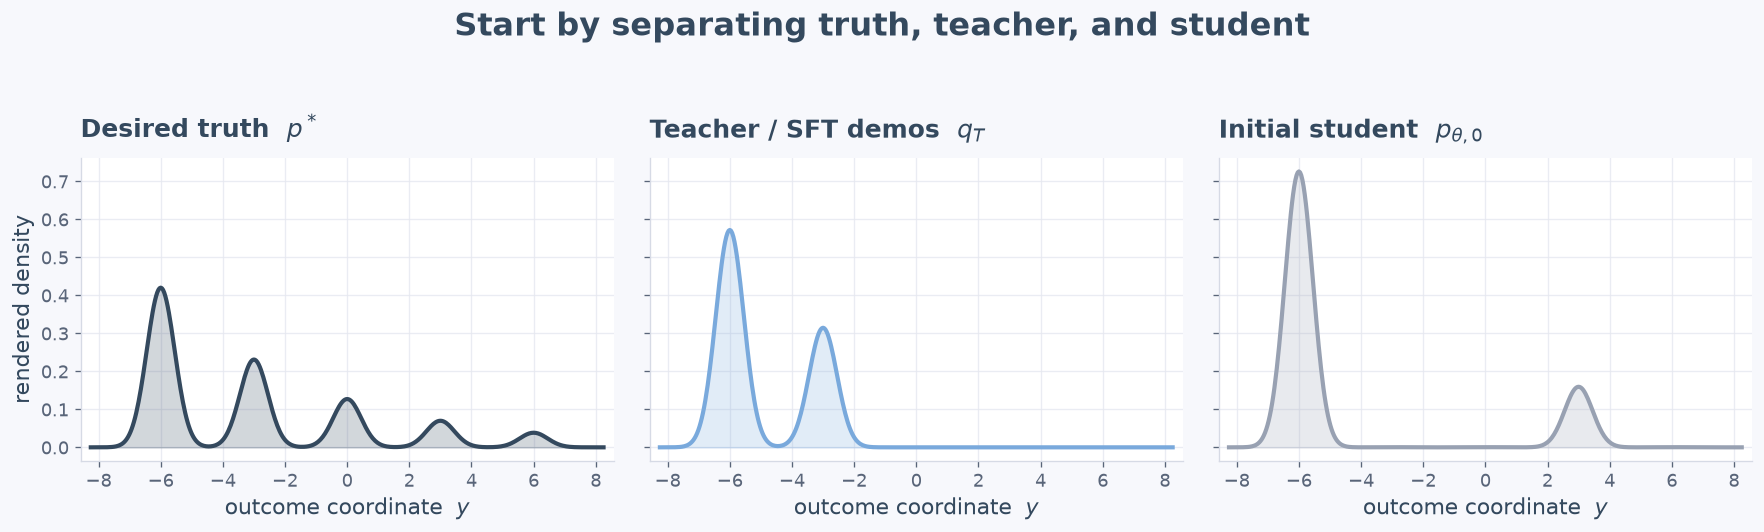

,method,final modal weights,KL(p* || p_theta),KL(p_theta || p*),KL(q_T || p_theta),KL(p_theta || q_T),mass on teacher-omitted truth modes,effective modes
0,SFT (teacher demos),"(0.64457, 0.35367, 1e-05, 0.00174, 1e-05)",1.76472e+00,2.99453e-01,0.00166,0.00671,0.00176,1.93869
1,forward-PD (full teacher),"(0.64457, 0.35367, 1e-05, 0.00174, 1e-05)",1.76472e+00,2.99453e-01,0.00166,0.00671,0.00176,1.93869
2,reverse-PD (student-weighted),"(0.64431, 0.35502, 1e-05, 0.00065, 1e-05)",1.85983e+00,3.04386e-01,0.00059,0.00190,0.00068,1.92695
3,pure RL: log p*,"(0.99968, 0.0, 0.0, 0.00032, 0.0)",5.63293e+00,7.44512e-01,4.39876,0.43883,0.00032,1.00294
4,truth-RL: log p* + entropy,"(0.47385, 0.26062, 0.14334, 0.07884, 0.04336)",-2.96484e-17,4.22505e-17,0.30821,2.13373,0.26554,3.74022


In [4]:
truth_problem = truth_mix.build_decaying_problem(
    mode_count=5,
    decay=0.55,
    teacher_omitted_modes=(2, 3, 4),
    omission_floor=1e-5,
    teacher_weight_power=1.0,
    initial_student_weights=(0.82, 0.0, 0.0, 0.18, 0.0),
    support_epsilon=5e-4,
    mode_spacing=3.0,
    component_std=0.45,
)
truth_config = truth_mix.TrajectoryConfig(
    steps=400,
    learning_rate=0.08,
    record_every=10,
)
truth_study = truth_mix.run_population_study(problem=truth_problem, config=truth_config)
truth_predictions = truth_study.predictions

mode_columns = [f"mode {index}" for index in range(truth_problem.mode_count)]
truth_setup_df = pd.DataFrame(
    [
        ["desired truth p*", *truth_problem.truth_weights.tolist()],
        ["teacher / SFT demos q_T", *truth_problem.teacher_weights.tolist()],
        ["initial student p_theta,0", *truth_problem.initial_student_weights.tolist()],
    ],
    columns=["distribution", *mode_columns],
)
display(truth_setup_df)

base_render = truth_mix.render_mixtures(truth_problem)
reference_panels = (
    ("Desired truth  $p^*$", base_render.truth_density, PASTEL["ink"]),
    ("Teacher / SFT demos  $q_T$", base_render.teacher_density, PASTEL["blue"]),
    ("Initial student  $p_{\\theta,0}$", base_render.student_density, PASTEL["muted"]),
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, sharey=True)
x_values = base_render.points.numpy()
for axis, (title, density, color) in zip(axes, reference_panels, strict=True):
    y_values = density.numpy()
    axis.plot(x_values, y_values, color=color, lw=2.5)
    axis.fill_between(x_values, y_values, color=color, alpha=0.22)
    axis.set_title(title, pad=12)
    axis.set_xlabel("outcome coordinate  $y$")
    axis.margins(x=0.02)
axes[0].set_ylabel("rendered density")
fig.suptitle("Start by separating truth, teacher, and student", y=1.02)
fig.tight_layout(pad=1.5)
plt.show()

truth_method_names = {
    "sft": "SFT (teacher demos)",
    "opd_fkl": "forward-PD (full teacher)",
    "opd_rkl": "reverse-PD (student-weighted)",
    "truth_rl": "pure RL: log p*",
    "truth_rl_entropy": "truth-RL: log p* + entropy",
}
truth_colors = {
    "sft": PASTEL["mint"],
    "opd_fkl": PASTEL["sage"],
    "opd_rkl": PASTEL["apricot"],
    "truth_rl": PASTEL["coral"],
    "truth_rl_entropy": PASTEL["lavender"],
}

truth_final_rows = []
for trajectory in truth_study.trajectories:
    metrics = trajectory.final.metrics
    truth_final_rows.append(
        {
            "method": truth_method_names[trajectory.method],
            "final modal weights": tuple(round(value, 5) for value in metrics.student_weights),
            "KL(p* || p_theta)": metrics.kl_truth_student,
            "KL(p_theta || p*)": metrics.kl_student_truth,
            "KL(q_T || p_theta)": metrics.kl_teacher_student,
            "KL(p_theta || q_T)": metrics.kl_student_teacher,
            "mass on teacher-omitted truth modes": metrics.student_omitted_teacher_mass,
            "effective modes": metrics.effective_support,
        }
    )
truth_final_df = pd.DataFrame(truth_final_rows)
display(truth_final_df)

sft_weights = np.asarray(truth_study.trajectory("sft").final.metrics.student_weights)
fkl_weights = np.asarray(truth_study.trajectory("opd_fkl").final.metrics.student_weights)
truth_rl_weights = np.asarray(
    truth_study.trajectory("truth_rl_entropy").final.metrics.student_weights
)
assert np.allclose(sft_weights, fkl_weights, atol=1e-12, rtol=0.0)
assert np.max(np.abs(truth_rl_weights - truth_problem.truth_weights.numpy())) < 1e-5

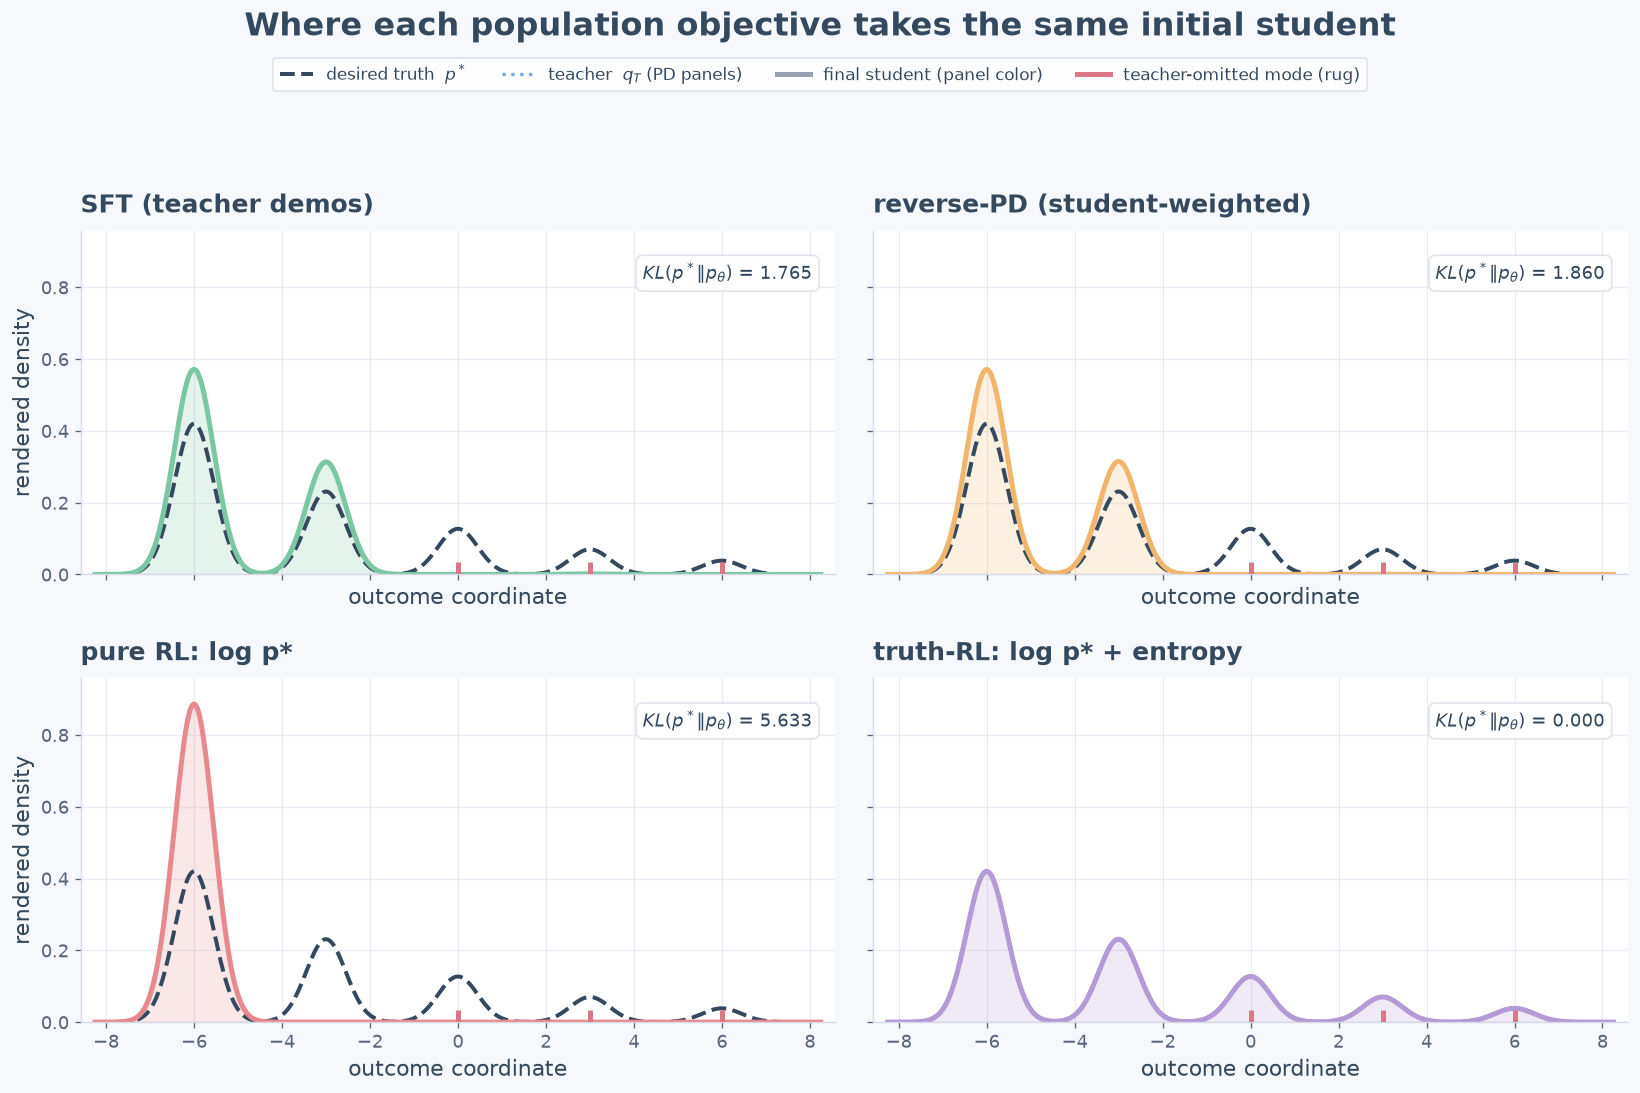

In [5]:
plot_methods = ("sft", "opd_rkl", "truth_rl", "truth_rl_entropy")
final_renders = {
    method: truth_mix.render_mixtures(
        truth_problem,
        student_weights=truth_study.trajectory(method).final.metrics.student_weights,
        points=base_render.points,
    )
    for method in plot_methods
}
all_densities = [
    base_render.truth_density,
    base_render.teacher_density,
    base_render.student_density,
    *(render.student_density for render in final_renders.values()),
]
common_ymax = 1.08 * max(float(density.max()) for density in all_densities)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, method in zip(axes.flat, plot_methods, strict=True):
    final_render = final_renders[method]
    x_values = base_render.points.numpy()
    final_density = final_render.student_density.numpy()
    axis.plot(
        x_values,
        base_render.truth_density.numpy(),
        color=PASTEL["ink"],
        lw=2.4,
        ls="--",
        label="desired truth  $p^*$",
    )
    if method in {"sft", "opd_rkl"}:
        axis.plot(
            x_values,
            base_render.teacher_density.numpy(),
            color=PASTEL["blue"],
            lw=2.0,
            ls=":",
            label="teacher target  $q_T$",
        )
    axis.plot(
        x_values,
        final_density,
        color=truth_colors[method],
        lw=3.0,
        label="final student",
    )
    axis.fill_between(x_values, final_density, color=truth_colors[method], alpha=0.20)
    axis.vlines(
        truth_problem.truth_mode_means[list(truth_problem.omitted_teacher_modes)].numpy(),
        0.0,
        0.035 * common_ymax,
        color=PASTEL["rose"],
        lw=3.0,
        zorder=5,
        label="teacher-omitted truth mode",
    )
    truth_kl = max(
        0.0,
        truth_study.trajectory(method).final.metrics.kl_truth_student,
    )
    axis.text(
        0.97,
        0.91,
        f"$KL(p^*\\Vert p_\\theta)$ = {truth_kl:.3f}",
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#E1E4EC"},
    )
    axis.set(title=truth_method_names[method], xlabel="outcome coordinate", ylim=(0, common_ymax))
    axis.margins(x=0.02)
axes[0, 0].set_ylabel("rendered density")
axes[1, 0].set_ylabel("rendered density")
legend_handles = [
    Line2D([], [], color=PASTEL["ink"], lw=2.4, ls="--", label="desired truth  $p^*$"),
    Line2D([], [], color=PASTEL["blue"], lw=2.0, ls=":", label="teacher  $q_T$ (PD panels)"),
    Line2D([], [], color=PASTEL["muted"], lw=3.0, label="final student (panel color)"),
    Line2D([], [], color=PASTEL["rose"], lw=3.0, label="teacher-omitted mode (rug)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.985))
fig.suptitle("Where each population objective takes the same initial student", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.94), pad=1.6)
plt.show()

The overlays answer the target question directly.  SFT and forward-PD are
identical here and approach the bimodal teacher.  Reverse-PD has the same
realizable teacher endpoint but follows a different, student-weighted path.
The mode identities already exist in the parameterization and $q_T$ has a
tiny positive floor, but neither teacher-only objective can recover the much
larger desired $p^*$ mass on those effectively omitted modes.
Pure $\log p^*$ reward correctly ranks the truth modes yet collapses onto the
largest one.  Adding exactly one unit of entropy turns that oracle RL
objective into $KL(p_\theta\|p^*)$, and it recovers the full decaying truth.

This is intentionally an information-source comparison: truth-RL is given
$\log p^*$ while distillation sees only $q_T$.  Its better truth fidelity is
not evidence that RL is intrinsically superior.  It says that no optimizer
can infer the desired mass of a teacher-omitted mode without another source
of information.  Literal hard support is tested separately below.

### Exact objectives versus sampled updates

The preceding curves use population expectations to identify targets.  The
actual estimators differ in what they sample:

- hard SFT samples modes from $q_T$;
- full-logit forward-PD has no conditional action-sampling noise;
- reverse-PD and both RL estimators sample modes from the current student.

At batch size $N$, mode $i$ appears with probability
$1-(1-\pi_i)^N$, using $\pi_i=q_{T,i}$ for SFT and
$\pi_i=p_{\theta,i}$ on policy.  We now estimate initial gradient noise over
128 seeds and compare it with the exact shared-loss gradient.
Absolute score-function SNR for sampled reverse-PD/RL depends on the chosen
baseline or group centering; the plot uses the estimators stated in the table
and should be read primarily through within-method scaling with $N$, not as a
universal ranking of optimizers.

,method,gradient_norm,gradient
0,hard SFT,4.33583e-01,"(0.17363690315301605, -0.35432496537268104, 0...."
1,forward-PD full logits,4.33583e-01,"(0.17363690315301605, -0.35432496537268104, 0...."
2,reverse-PD sampled,1.92673e+00,"(-1.3611388863199552, -0.00422717417842796, 0...."
3,pure RL sampled,3.74542e-01,"(-0.2656404969448048, 0.00013649488141530806, ..."
4,truth-RL + entropy sampled,5.43055e-02,"(-0.033419776800521904, -0.003417589355550258,..."
5,RL: every mode valid,1.86133e-16,"(1.8180387023317593e-16, 1.1085601843486342e-1..."


,method_label,batch_size,exact_gradient_norm,noise_rms,snr,bias_norm,cosine_of_mean_to_exact
0,hard SFT,8,4.33583e-01,0.25267,1.71600,4.64179e-03,0.99998
1,forward-PD full logits,8,4.33583e-01,0.00000,inf,1.11022e-16,1.00000
2,reverse-PD sampled,8,1.92673e+00,1.42907,1.34825,6.40249e-02,1.00000
3,pure RL sampled,8,3.74542e-01,0.40624,0.92197,1.93137e-02,0.99998
4,truth-RL + entropy sampled,8,5.43055e-02,0.16151,0.33623,7.34868e-03,0.99535
5,RL: every mode valid,8,1.86133e-16,0.18360,0.00000,8.76494e-03,NaN
12,hard SFT,128,4.33583e-01,0.06433,6.74028,6.49332e-03,0.99997
13,forward-PD full logits,128,4.33583e-01,0.00000,inf,1.11022e-16,1.00000
14,reverse-PD sampled,128,1.92673e+00,0.38307,5.02975,2.11569e-02,1.00000
15,pure RL sampled,128,3.74542e-01,0.10913,3.43202,6.70291e-03,0.99999


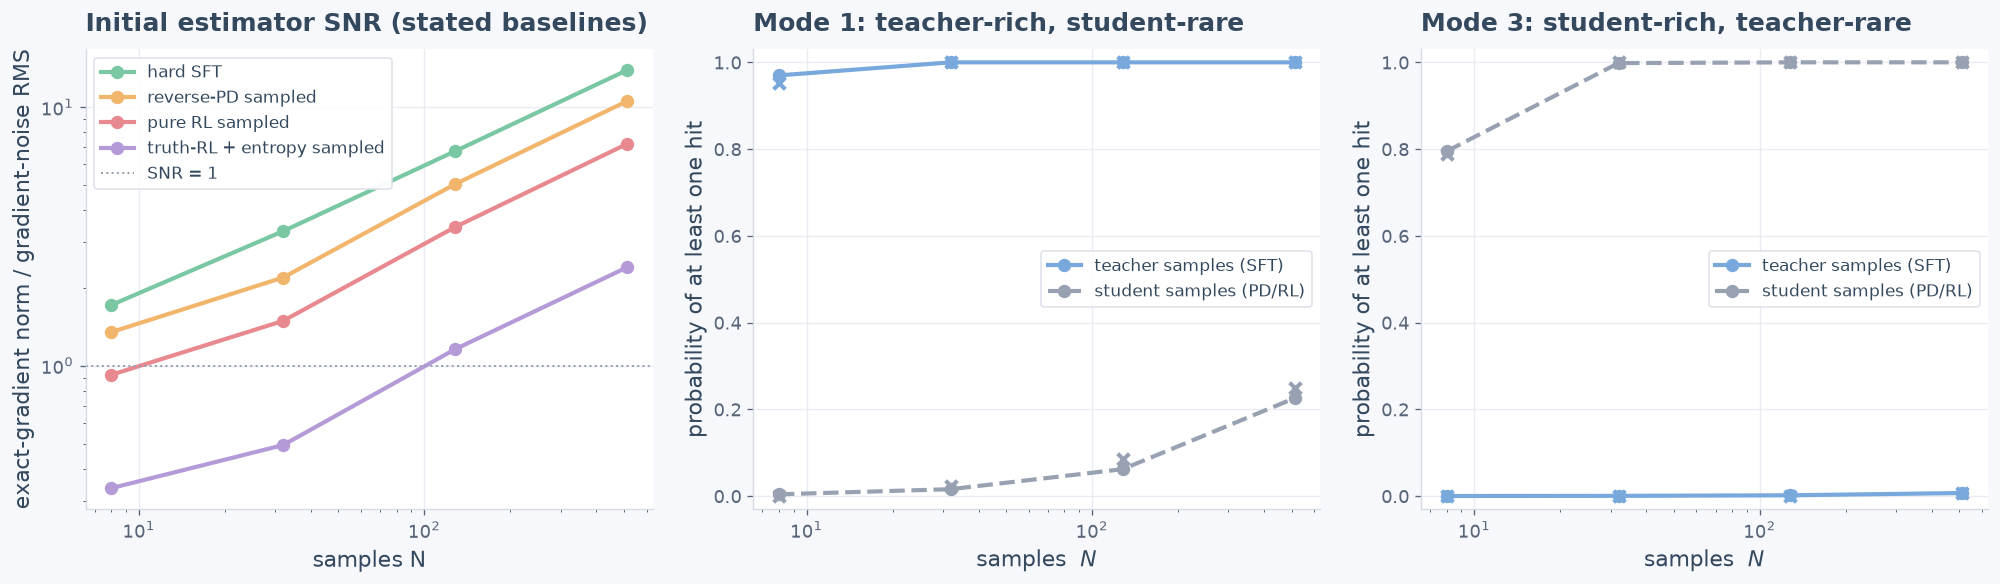

In [6]:
truth_sampling_study = truth_sampling.run_truth_sampling_study(
    truth_problem.truth_weights,
    truth_problem.teacher_weights,
    truth_problem.initial_student_weights,
    config=truth_sampling.SamplingConfig(
        batch_sizes=(8, 32, 128, 512),
        seeds=tuple(range(128)),
    ),
)
sampling_method_names = {
    "sft_hard": "hard SFT",
    "opd_fkl_full": "forward-PD full logits",
    "opd_rkl": "reverse-PD sampled",
    "rl_pure_truth": "pure RL sampled",
    "rl_entropy_truth": "truth-RL + entropy sampled",
    "rl_constant_validity": "RL: every mode valid",
}
sampling_exact_df = pd.DataFrame(truth_sampling.exact_rows(truth_sampling_study))
sampling_exact_df["method"] = sampling_exact_df.method.map(sampling_method_names)
display(sampling_exact_df[["method", "gradient_norm", "gradient"]])

sampling_summary_df = pd.DataFrame(truth_sampling.summary_rows(truth_sampling_study))
sampling_summary_df["method_label"] = sampling_summary_df.method.map(sampling_method_names)
display(
    sampling_summary_df[
        sampling_summary_df.batch_size.isin((8, 128))
    ][
        [
            "method_label",
            "batch_size",
            "exact_gradient_norm",
            "noise_rms",
            "snr",
            "bias_norm",
            "cosine_of_mean_to_exact",
        ]
    ]
)

sampling_discovery_df = pd.DataFrame(truth_sampling.discovery_rows(truth_sampling_study))
sampling_colors = {
    "sft_hard": PASTEL["mint"],
    "opd_rkl": PASTEL["apricot"],
    "rl_pure_truth": PASTEL["coral"],
    "rl_entropy_truth": PASTEL["lavender"],
}
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for method in ("sft_hard", "opd_rkl", "rl_pure_truth", "rl_entropy_truth"):
    group = sampling_summary_df[sampling_summary_df.method == method].sort_values("batch_size")
    axes[0].plot(
        group.batch_size,
        group.snr,
        "o-",
        color=sampling_colors[method],
        label=sampling_method_names[method],
    )
axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="samples N",
    ylabel="exact-gradient norm / gradient-noise RMS",
    title="Initial estimator SNR (stated baselines)",
)
axes[0].axhline(1.0, color=PASTEL["muted"], lw=1.2, ls=":", label="SNR = 1")
axes[0].legend()

discovery_styles = {
    (1, "teacher"): (PASTEL["blue"], "-", "teacher samples (SFT)"),
    (1, "student"): (PASTEL["muted"], "--", "student samples (PD/RL)"),
    (3, "teacher"): (PASTEL["blue"], "-", "teacher samples (SFT)"),
    (3, "student"): (PASTEL["muted"], "--", "student samples (PD/RL)"),
}
for (mode, source), (color, line_style, label) in discovery_styles.items():
    group = sampling_discovery_df[
        (sampling_discovery_df["mode"] == mode) & (sampling_discovery_df.source == source)
    ].sort_values("batch_size")
    axis = axes[1] if mode == 1 else axes[2]
    axis.plot(
        group.batch_size,
        group.predicted_hit_probability,
        color=color,
        ls=line_style,
        marker="o",
        label=label,
    )
    axis.scatter(
        group.batch_size,
        group.observed_hit_rate,
        color=color,
        marker="x",
        zorder=4,
    )
for axis, _mode, title in (
    (axes[1], 1, "Mode 1: teacher-rich, student-rare"),
    (axes[2], 3, "Mode 3: student-rich, teacher-rare"),
):
    axis.set(
        xscale="log",
        xlabel="samples  $N$",
        ylabel="probability of at least one hit",
        title=title,
        ylim=(-0.03, 1.03),
    )
    axis.legend()
fig.tight_layout(pad=1.6)
plt.show()

exact_sft_gradient = sampling_exact_df.loc[
    sampling_exact_df.method == sampling_method_names["sft_hard"], "gradient"
].iloc[0]
exact_fkl_gradient = sampling_exact_df.loc[
    sampling_exact_df.method == sampling_method_names["opd_fkl_full"], "gradient"
].iloc[0]
constant_reward_norm = float(
    sampling_exact_df.loc[
        sampling_exact_df.method == sampling_method_names["rl_constant_validity"], "gradient_norm"
    ].iloc[0]
)
assert np.allclose(exact_sft_gradient, exact_fkl_gradient, atol=1e-12, rtol=0.0)
assert constant_reward_norm < 1e-12
assert sampling_summary_df[
    sampling_summary_df.method == "opd_fkl_full"
].noise_rms.max() == 0.0

Mode 1 is common under the teacher but initially rare under the student, so
SFT/full forward-PD can teach it immediately while sampled reverse-PD/RL
usually do not even observe it at small $N$.  Mode 3 has the opposite
asymmetry: the student visits it frequently, but teacher demonstrations
effectively omit it.  This is the one-state action analogue of why
student-prefix collection can expose different states in a sequence.
A “hit” means direct mode-specific teacher/reward information; softmax
normalization and shared parameters can still move an unobserved mode
indirectly.

The “every mode is valid” RL control has exactly zero population gradient.
Its finite-batch movement is only score noise (and disappears completely
with a batch-constant baseline).  Binary correctness can preserve or select
validity, but it cannot identify the decaying relative frequencies in
$p^*$.  A distance or verifier reward similarly determines a utility
optimum; it recovers a distribution only after an explicit calibration or
regularizer makes that distribution the optimum.

### Pure RL depends on the reward: log density, binary match, or distance

The red primary curve above uses the dense oracle reward
$U(a)=\log p^*(a)$.  It is neither a binary verifier nor the geometric
distance to a sampled answer.  In fact, because this benchmark has geometric
truth weights and equally spaced modes, $\log p_i^*$ is affine-equivalent to
*linear distance from the dominant mode*.  Adding that particular distance
reward would therefore be a duplicate experiment.

To test genuinely different reward information, draw one reference
$T\sim p^*$ and compare

$$
R_{bin}(T,a)=\mathbf 1[a=T],\qquad
R_{dist}(T,a)=-\left(\frac{\mu_a-\mu_T}{\Delta}\right)^2,
$$

where $\Delta$ is one mode spacing.  Marginalizing the reference gives the
fixed utilities supplied to ordinary population RL:

$$
u_{bin}(a)=p^*(a),\qquad
u_{dist}(a)=-\mathbb E_{T\sim p^*}
\left[\left(\frac{\mu_a-\mu_T}{\Delta}\right)^2\right].
$$

Pure RL always selects a maximizer of its supplied utility.  For this default
truth, log-density and binary-reference rewards select mode 0, whereas
squared distance selects mode 1, the discrete mode nearest the truth mean.
With entropy coefficient $\alpha$, the endpoint is
$p_\alpha(a)\propto e^{u(a)/\alpha}$; only
$u(a)=\alpha\log p^*(a)+C$ recovers $p^*$.  A binary reward declaring every
truth-supported mode valid is constant here and has zero learning signal, as
the control above already verifies.

,reward,expected utility by action,pure-RL maximizing mode(s),entropy endpoint (alpha=1),"TV(entropy endpoint, p*)"
0,Oracle log-density $\log p^*$,"(-0.7469, -1.3447, -1.9425, -2.5404, -3.1382)","(0,)","(0.4738, 0.2606, 0.1433, 0.0788, 0.0434)",2.08167e-17
1,Binary reference match,"(0.4738, 0.2606, 0.1433, 0.0788, 0.0434)","(0,)","(0.2597, 0.2098, 0.1866, 0.175, 0.1689)",2.64910e-01
2,Squared reference distance,"(-2.2373, -1.3228, -2.4083, -5.4938, -10.5793)","(1,)","(0.2285, 0.5701, 0.1925, 0.0088, 0.0001)",3.58725e-01


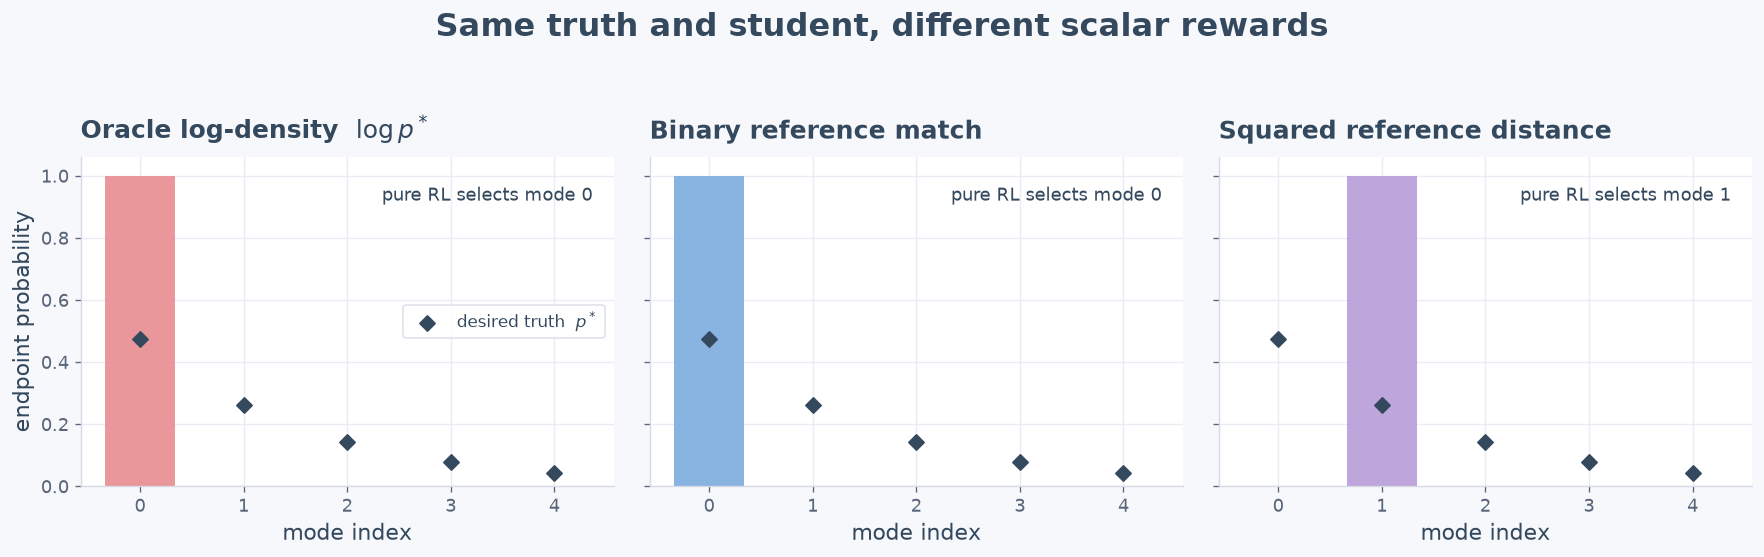

In [7]:
reward_kinds = (
    "oracle_log_density",
    "binary_reference",
    "squared_distance_reference",
)
reward_names = {
    "oracle_log_density": r"Oracle log-density  $\log p^*$",
    "binary_reference": "Binary reference match",
    "squared_distance_reference": "Squared reference distance",
}
reward_colors = {
    "oracle_log_density": PASTEL["coral"],
    "binary_reference": PASTEL["blue"],
    "squared_distance_reference": PASTEL["lavender"],
}
reward_line_styles = {
    "oracle_log_density": {"ls": "-", "marker": "o"},
    "binary_reference": {"ls": "--", "marker": "s"},
    "squared_distance_reference": {"ls": ":", "marker": "D"},
}
reward_landscapes = {
    kind: truth_reward.build_mixture_reward_landscape(truth_problem, kind=kind)
    for kind in reward_kinds
}

reward_semantics_rows = []
for kind, landscape in reward_landscapes.items():
    entropy_tv = 0.5 * (landscape.entropy_endpoint - landscape.truth_probs).abs().sum()
    reward_semantics_rows.append(
        {
            "reward": reward_names[kind],
            "expected utility by action": tuple(
                round(float(value), 4) for value in landscape.expected_utility
            ),
            "pure-RL maximizing mode(s)": landscape.maximizing_modes,
            "entropy endpoint (alpha=1)": tuple(
                round(float(value), 4) for value in landscape.entropy_endpoint
            ),
            "TV(entropy endpoint, p*)": float(entropy_tv),
        }
    )
reward_semantics_df = pd.DataFrame(reward_semantics_rows)
display(reward_semantics_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
mode_indices = np.arange(truth_problem.mode_count)
for axis, kind in zip(axes, reward_kinds, strict=True):
    landscape = reward_landscapes[kind]
    endpoint = landscape.pure_endpoint.numpy()
    axis.bar(mode_indices, endpoint, width=0.68, color=reward_colors[kind], alpha=0.88)
    axis.scatter(
        mode_indices,
        landscape.truth_probs.numpy(),
        color=PASTEL["ink"],
        marker="D",
        s=42,
        zorder=4,
        label="desired truth  $p^*$",
    )
    selected = ", ".join(str(mode) for mode in landscape.maximizing_modes)
    axis.set(title=reward_names[kind], xlabel="mode index", ylim=(0.0, 1.06))
    axis.set_xticks(mode_indices)
    axis.text(
        0.96,
        0.91,
        f"pure RL selects mode {selected}",
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=10.5,
    )
axes[0].set_ylabel("endpoint probability")
axes[0].legend(loc="center right")
fig.suptitle("Same truth and student, different scalar rewards", y=1.02)
fig.tight_layout(pad=1.5)
plt.show()

assert torch.allclose(
    reward_landscapes["oracle_log_density"].entropy_endpoint,
    truth_problem.truth_weights,
    atol=1e-12,
    rtol=0.0,
)
assert reward_landscapes["binary_reference"].maximizing_modes == (0,)
assert reward_landscapes["squared_distance_reference"].maximizing_modes == (1,)

For the GRPO-style estimator, each group draws one reference $T_b$ and $G$
student completions, then uses Prime-RL's default **unnormalized** group
centering:

$$
\widehat A_{b,g}=R(T_b,A_{b,g})-
\frac{1}{G}\sum_{j=1}^{G}R(T_b,A_{b,j}).
$$

At a fresh policy its expected update direction is exactly $(G-1)/G$ times
ordinary policy gradient.  Thus $G=1$ is always a no-op; for $G>1$ centering
preserves direction but changes scale.  A group has signal only if it spans
at least two reward-equivalence classes.  The following sweep keeps the total
budget fixed at 32 completions and changes only their grouping.  This is the
group-relative score-function core, not the full LLM trainer: there is no
clipping, sequence credit assignment, or reference-policy KL here.  We also
leave standard-deviation normalization off because, for three or more reward
levels, it can change the population direction rather than merely its scale.

,reward_label,group_size,groups_per_batch,expected_update_norm,noise_rms,snr,cosine_of_mean_to_expected,predicted_informative_group_probability,observed_informative_group_probability,observed_no_op_rate
0,Oracle log-density $\log p^*$,1,32,0.00000,0.00000,NaN,NaN,0.00000,0.00000,1.00000
3,Oracle log-density $\log p^*$,8,4,0.32772,0.09828,3.33454,1.00000,0.79802,0.79810,0.00000
4,Oracle log-density $\log p^*$,16,2,0.35113,0.10272,3.41832,1.00000,0.95921,0.96289,0.00000
5,Binary reference match,1,32,0.00000,0.00000,NaN,NaN,0.00000,0.00000,1.00000
8,Binary reference match,8,4,0.07219,0.07074,1.02047,0.99999,0.44260,0.44482,0.11523
9,Binary reference match,16,2,0.07735,0.09581,0.80728,1.00000,0.53360,0.53369,0.22656
10,Squared reference distance,1,32,0.00000,0.00000,NaN,NaN,0.00000,0.00000,1.00000
13,Squared reference distance,8,4,0.59507,0.77010,0.77271,1.00000,0.79762,0.79736,0.01758
14,Squared reference distance,16,2,0.63757,1.03557,0.61567,1.00000,0.95904,0.96289,0.01953


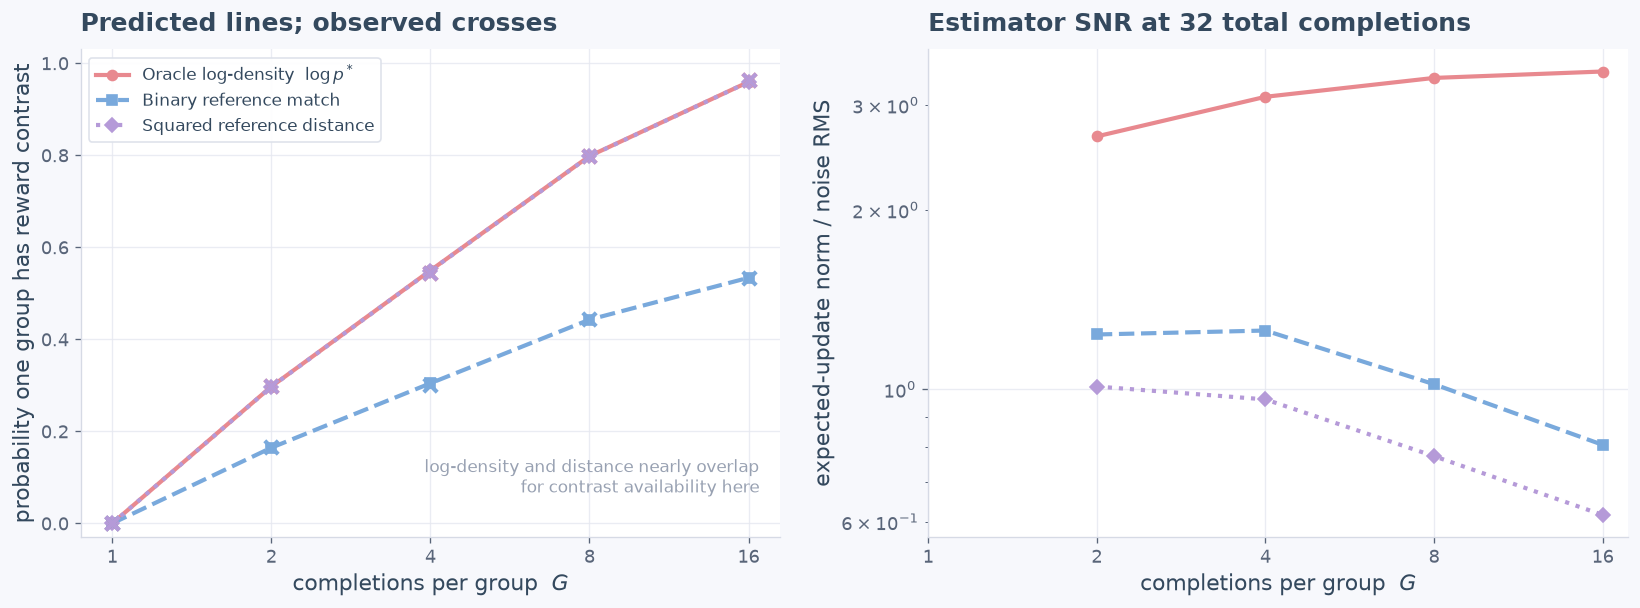

In [8]:
group_reward_config = truth_reward.GroupSamplingConfig(
    group_sizes=(1, 2, 4, 8, 16),
    total_completions=32,
    batches_per_seed=256,
    seeds=(0, 1, 2, 3),
)
group_reward_studies = {
    kind: truth_reward.run_group_sampling_study(
        landscape,
        truth_problem.initial_student_weights,
        config=group_reward_config,
    )
    for kind, landscape in reward_landscapes.items()
}
group_reward_df = pd.concat(
    [pd.DataFrame(study.rows()) for study in group_reward_studies.values()],
    ignore_index=True,
)
group_reward_df["reward_label"] = group_reward_df.reward_kind.map(reward_names)
display(
    group_reward_df[group_reward_df.group_size.isin((1, 8, 16))][
        [
            "reward_label",
            "group_size",
            "groups_per_batch",
            "expected_update_norm",
            "noise_rms",
            "snr",
            "cosine_of_mean_to_expected",
            "predicted_informative_group_probability",
            "observed_informative_group_probability",
            "observed_no_op_rate",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for kind in reward_kinds:
    group = group_reward_df[group_reward_df.reward_kind == kind].sort_values("group_size")
    color = reward_colors[kind]
    style = reward_line_styles[kind]
    axes[0].plot(
        group.group_size,
        group.predicted_informative_group_probability,
        color=color,
        ls=style["ls"],
        marker=style["marker"],
        ms=6,
        label=reward_names[kind],
    )
    axes[0].scatter(
        group.group_size,
        group.observed_informative_group_probability,
        color=color,
        marker="x",
        s=65,
        zorder=4,
    )
    nonzero = group[group.group_size > 1]
    axes[1].plot(
        nonzero.group_size,
        nonzero.snr,
        color=color,
        ls=style["ls"],
        marker=style["marker"],
        ms=6,
        label=reward_names[kind],
    )
axes[0].set(
    xlabel="completions per group  $G$",
    ylabel="probability one group has reward contrast",
    title="Predicted lines; observed crosses",
    ylim=(-0.03, 1.03),
)
axes[1].set(
    xlabel="completions per group  $G$",
    ylabel="expected-update norm / noise RMS",
    title="Estimator SNR at 32 total completions",
    yscale="log",
)
axes[0].text(
    0.97,
    0.08,
    "log-density and distance nearly overlap\nfor contrast availability here",
    transform=axes[0].transAxes,
    ha="right",
    va="bottom",
    color=PASTEL["muted"],
    fontsize=10,
)
for axis in axes:
    axis.set_xscale("log", base=2)
    axis.set_xticks(group_reward_config.group_sizes, group_reward_config.group_sizes)
axes[0].legend()
fig.tight_layout(pad=1.6)
plt.show()

for study in group_reward_studies.values():
    assert study.summary(1).observed_no_op_rate == 1.0
    for group_size in (2, 4, 8, 16):
        cosine = study.summary(group_size).cosine_of_mean_to_expected
        assert cosine is not None and cosine > 0.99

### Teacher defects predict irreducible distillation bias

The next matrix changes one teacher defect at a time, then increases the
decaying truth from five to eight modes while the teacher still keeps only
two.  It uses analytic population endpoints, not fitted curves.  Total
variation to (p^*) is finite even for the one-hot pure-RL endpoint.  Student
initialization affects finite-time reachability, but not these realizable
endpoints.

,scenario,teacher weights,teacher TV from truth
0,teacher = truth (n=5),"(0.4738, 0.2606, 0.1433, 0.0788, 0.0434)",0.00000
1,teacher top 2 + ε floor (n=5),"(0.6451, 0.3548, 1.4e-05, 1.4e-05, 1.4e-05)",0.26549
2,teacher top 2 + ε floor (n=8),"(0.6451, 0.3548, 1.4e-05, 1.4e-05, 1.4e-05, 1....",0.29652
3,teacher misses head + ε floor (n=5),"(1.9e-05, 0.4953, 0.2724, 0.1498, 0.0824)",0.47383
4,teacher sharpens weights (n=5),"(0.6993, 0.2115, 0.0640, 0.0194, 0.0059)",0.22542


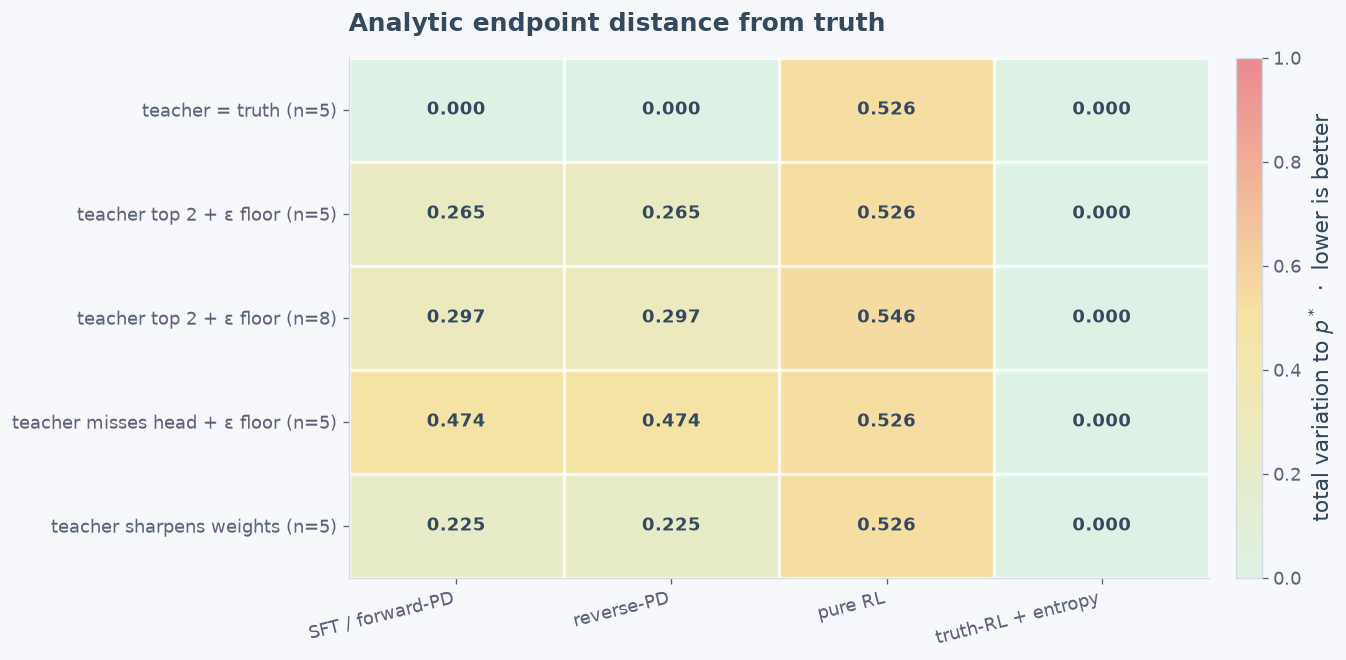

In [9]:
scenario_specs = {
    "teacher = truth (n=5)": {
        "mode_count": 5,
        "teacher_omitted_modes": (),
        "teacher_weight_power": 1.0,
    },
    "teacher top 2 + ε floor (n=5)": {
        "mode_count": 5,
        "teacher_omitted_modes": (2, 3, 4),
        "teacher_weight_power": 1.0,
    },
    "teacher top 2 + ε floor (n=8)": {
        "mode_count": 8,
        "teacher_omitted_modes": (2, 3, 4, 5, 6, 7),
        "teacher_weight_power": 1.0,
    },
    "teacher misses head + ε floor (n=5)": {
        "mode_count": 5,
        "teacher_omitted_modes": (0,),
        "teacher_weight_power": 1.0,
    },
    "teacher sharpens weights (n=5)": {
        "mode_count": 5,
        "teacher_omitted_modes": (),
        "teacher_weight_power": 2.0,
    },
}
endpoint_names = ("SFT / forward-PD", "reverse-PD", "pure RL", "truth-RL + entropy")
endpoint_tv = np.zeros((len(scenario_specs), len(endpoint_names)))
scenario_rows = []
for row_index, (scenario, specification) in enumerate(scenario_specs.items()):
    mode_count = specification["mode_count"]
    initial_weights = [0.0] * mode_count
    initial_weights[0] = 0.82
    initial_weights[min(3, mode_count - 1)] = 0.18
    problem = truth_mix.build_decaying_problem(
        mode_count=mode_count,
        decay=0.55,
        omission_floor=1e-5,
        initial_student_weights=initial_weights,
        support_epsilon=5e-4,
        teacher_omitted_modes=specification["teacher_omitted_modes"],
        teacher_weight_power=specification["teacher_weight_power"],
    )
    prediction = truth_mix.theory_predictions(problem)
    endpoints = (
        prediction.sft_fkl_endpoint,
        prediction.opd_rkl_endpoint,
        prediction.pure_truth_rl_endpoint,
        prediction.entropy_truth_rl_endpoint,
    )
    if any(endpoint is None for endpoint in endpoints):
        raise RuntimeError("the floored, full-capacity sweep should have finite endpoints")
    for column_index, endpoint in enumerate(endpoints):
        endpoint_tensor = torch.tensor(endpoint)
        endpoint_tv[row_index, column_index] = float(
            0.5 * (endpoint_tensor - problem.truth_weights).abs().sum()
        )
    scenario_rows.append(
        {
            "scenario": scenario,
            "teacher weights": tuple(
                f"{float(value):.4f}" if float(value) >= 1e-3 else f"{float(value):.1e}"
                for value in problem.teacher_weights
            ),
            "teacher TV from truth": float(
                0.5 * (problem.teacher_weights - problem.truth_weights).abs().sum()
            ),
        }
    )
display(pd.DataFrame(scenario_rows))

fig, axis = plt.subplots(figsize=(12, 5.8))
image_handle = axis.imshow(endpoint_tv, vmin=0.0, vmax=1.0, cmap=PASTEL_RISK_CMAP, aspect="auto")
axis.grid(False)
axis.set_xticks(np.arange(len(endpoint_names)), endpoint_names, rotation=14, ha="right")
axis.set_yticks(np.arange(len(scenario_specs)), tuple(scenario_specs))
axis.set_xticks(np.arange(-0.5, len(endpoint_names), 1), minor=True)
axis.set_yticks(np.arange(-0.5, len(scenario_specs), 1), minor=True)
axis.grid(which="minor", color="white", linewidth=2.0)
axis.tick_params(which="minor", bottom=False, left=False)
axis.set_title("Analytic endpoint distance from truth", pad=16)
for row_index in range(endpoint_tv.shape[0]):
    for column_index in range(endpoint_tv.shape[1]):
        value = endpoint_tv[row_index, column_index]
        axis.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=PASTEL["ink"] if value < 0.72 else "white",
        )
colorbar = fig.colorbar(image_handle, ax=axis, pad=0.025)
colorbar.set_label("total variation to $p^*$  ·  lower is better")
fig.tight_layout(pad=1.5)
plt.show()

assert endpoint_tv[0, :2].max() < 1e-12
assert endpoint_tv[:, 3].max() < 1e-12

The omission rows use the displayed positive epsilon floor.  With an exact
categorical teacher zero and any reachable student mass on that mode,
(KL(p_\theta\|q_T)=\infty); the experiment code marks reverse-PD unavailable
rather than silently smoothing it.  A hard student capacity mask is a
different case again: no method can create a structurally absent mode.

### Literal translation: who weights the displaced mode?

Now the teacher's second mode is shifted by (1.5), while truth and the
initial student component locations agree.  The student is deliberately
restricted to one shared translation parameter, so it cannot move only that
component.  This optional location control is the **labeled joint** model
(p(i,y)): mode identity (i) is observed, and each conditional (y\mid i) is
Gaussian.  The marginal Gaussian curve is only a visualization.  These
weighted formulas are not asserted for a generic unlabeled overlapping
mixture.  At the initial checkpoint,

$$
-\nabla_\tau L_{F}\propto
\sum_i q_{T,i}(\mu^T_i-\mu^S_i),\qquad
-\nabla_\tau L_{R}\propto
\sum_i p_{\theta,i}(\mu^T_i-\mu^S_i).
$$

Forward training sees the displaced teacher mode with its order-one teacher
mass.  Reverse-PD barely weights it because the initial student probability
there is only the epsilon floor.  Truth-reward RL ignores this teacher error.

,method,weighting_distribution,initial_translation,loss,gradient,descent_direction,component_gradients,component_descent_directions
0,SFT (teacher demos),teacher,0.0,4.79799,-2.62833,2.62833,"(0.0, -2.6283275295999706, 0.0, 0.0, 0.0)","(-0.0, 2.6283275295999706, -0.0, -0.0, -0.0)"
1,forward-PD (full teacher),teacher,0.0,4.79799,-2.62833,2.62833,"(0.0, -2.6283275295999706, 0.0, 0.0, 0.0)","(-0.0, 2.6283275295999706, -0.0, -0.0, -0.0)"
2,reverse-PD (student-weighted),student,0.0,1.90353,-0.00370,0.00370,"(0.0, -0.0036981564690002034, 0.0, 0.0, 0.0)","(-0.0, 0.0036981564690002034, -0.0, -0.0, -0.0)"
3,pure RL: log p*,student,0.0,1.07131,0.00000,-0.00000,"(0.0, 0.0, 0.0, 0.0, 0.0)","(-0.0, -0.0, -0.0, -0.0, -0.0)"
4,truth-RL: log p* + entropy,student,0.0,0.58774,0.00000,-0.00000,"(0.0, 0.0, 0.0, 0.0, 0.0)","(-0.0, -0.0, -0.0, -0.0, -0.0)"


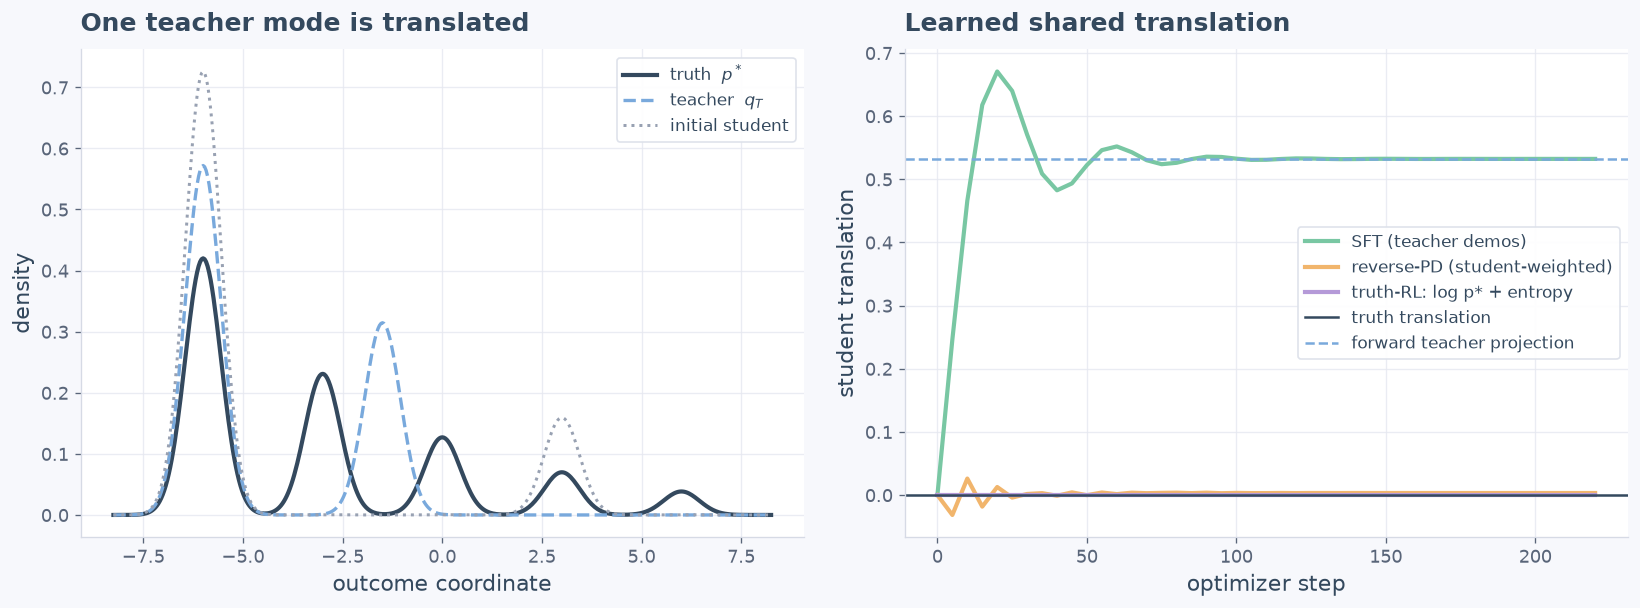

In [10]:
translation_problem = truth_mix.build_decaying_problem(
    mode_count=5,
    decay=0.55,
    teacher_omitted_modes=(2, 3, 4),
    omission_floor=1e-5,
    teacher_weight_power=1.0,
    initial_student_weights=(0.82, 0.0, 0.0, 0.18, 0.0),
    support_epsilon=5e-4,
    mode_spacing=3.0,
    component_std=0.45,
    teacher_component_shifts=(0.0, 1.5, 0.0, 0.0, 0.0),
)
translation_methods = ("sft", "opd_fkl", "opd_rkl", "truth_rl", "truth_rl_entropy")
location_gradient_df = pd.DataFrame(
    [
        asdict(truth_mix.exact_initial_location_gradient(method, translation_problem))
        for method in translation_methods
    ]
)
location_gradient_df["method"] = location_gradient_df.method.map(truth_method_names)
display(location_gradient_df)

translation_config = truth_mix.TrajectoryConfig(steps=220, learning_rate=0.05, record_every=5)
translation_trajectories = [
    truth_mix.run_labeled_location_trajectory(
        method,
        problem=translation_problem,
        config=translation_config,
    )
    for method in ("sft", "opd_rkl", "truth_rl_entropy")
]
translation_df = pd.DataFrame(
    [record for trajectory in translation_trajectories for record in trajectory.records()]
)
translation_render = truth_mix.render_mixtures(translation_problem)
teacher_projection = float(
    torch.dot(
        translation_problem.teacher_weights,
        translation_problem.teacher_mode_means - translation_problem.student_mode_means,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
axes[0].plot(
    translation_render.points,
    translation_render.truth_density,
    color=PASTEL["ink"],
    lw=2.5,
    label="truth  $p^*$",
)
axes[0].plot(
    translation_render.points,
    translation_render.teacher_density,
    color=PASTEL["blue"],
    lw=2,
    ls="--",
    label="teacher  $q_T$",
)
axes[0].plot(
    translation_render.points,
    translation_render.student_density,
    color=PASTEL["muted"],
    lw=1.8,
    ls=":",
    label="initial student",
)
axes[0].set(title="One teacher mode is translated", xlabel="outcome coordinate", ylabel="density")
axes[0].legend()

for trajectory in translation_trajectories:
    group = translation_df[translation_df.method == trajectory.method]
    axes[1].plot(
        group.step,
        group.translation,
        label=truth_method_names[trajectory.method],
        color=truth_colors[trajectory.method],
    )
axes[1].axhline(0.0, color=PASTEL["ink"], lw=1.5, label="truth translation")
axes[1].axhline(
    teacher_projection,
    color=PASTEL["blue"],
    lw=1.5,
    ls="--",
    label="forward teacher projection",
)
axes[1].set(title="Learned shared translation", xlabel="optimizer step", ylabel="student translation")
axes[1].legend()
fig.tight_layout(pad=1.6)
plt.show()

sft_location_signal = float(
    location_gradient_df.loc[location_gradient_df.method == truth_method_names["sft"], "descent_direction"].iloc[0]
)
rkl_location_signal = float(
    location_gradient_df.loc[
        location_gradient_df.method == truth_method_names["opd_rkl"], "descent_direction"
    ].iloc[0]
)
shifted_mode = 1
mode_displacement = float(
    translation_problem.teacher_mode_means[shifted_mode]
    - translation_problem.student_mode_means[shifted_mode]
)
expected_sft_location_signal = float(
    translation_problem.teacher_weights[shifted_mode]
    * mode_displacement
    / translation_problem.component_std**2
)
expected_rkl_location_signal = float(
    translation_problem.initial_student_weights[shifted_mode]
    * mode_displacement
    / translation_problem.component_std**2
)
assert np.isclose(sft_location_signal, expected_sft_location_signal, atol=1e-12, rtol=0.0)
assert np.isclose(rkl_location_signal, expected_rkl_location_signal, atol=1e-12, rtol=0.0)

The initial raw location signal differs by roughly three orders of magnitude.
SFT/forward-PD moves toward the teacher-mass-weighted compromise.  From this
initialization, reverse-PD instead avoids the displaced, initially rare
component for hundreds of steps; this is a finite optimizer path under the
stated one-translation bottleneck, not a claim about every RKL global
optimum.  Calibrated truth-RL stays at the correct truth location.

In the translation analogy, a mode can be a semantic equivalence class of
valid renderings.  A literal location shift represents a systematic style or
calibration bias inside a class; modal omission represents a valid class the
teacher never emits.  These are different teacher defects and should not be
collapsed into one scalar “teacher quality.”

## 4. Implementation sidebar — the current sparse top-k OPD branch

Prime-RL's teacher-top-k-plus-sampled-token loss at a fixed context is

$$
L_y=\sum_{i\in H}p_i\log\frac{p_i}{q_i}
+\mathbf 1[y\notin H]p_y\log\frac{p_y}{q_y},\qquad y\sim b.
$$

Holding rollout distribution (b) fixed during backpropagation, its exact
expected gradient has coefficient (1) on teacher top-k and (b_i) outside
it.  For fresh on-policy data, omitted terms are therefore effectively
weighted by (p_i^2), not (p_i).

This is not a small semantic distinction: a partial sum of full-normalized
KL terms is not itself a KL.  It can point opposite full RKL, and the teacher
is generally not a fixed point for (k<V).

,k,omitted_p_mass,full_gradient_norm,union_gradient_norm,relation
0,1,0.55,0.0,0.23036,full-stationary
1,2,0.30,0.0,0.17539,full-stationary
2,3,0.15,0.0,0.10723,full-stationary
3,4,0.07,0.0,0.06004,full-stationary
4,5,0.02,0.0,0.02197,full-stationary
5,6,0.00,0.0,0.00000,full-stationary


,k,omitted_p_mass,cosine,directional_gain,relative_bias,relation
0,1,0.65,-0.57099,-0.37167,1.47208e+00,opposes
1,2,0.40,-0.49703,-0.34549,1.47451e+00,opposes
2,3,0.30,-0.60916,-0.36330,1.44302e+00,opposes
3,4,0.20,-0.48551,-0.25090,1.32998e+00,opposes
4,5,0.10,0.10178,0.05896,1.10348e+00,aligns
5,6,0.00,1.00000,1.00000,3.33989e-16,aligns


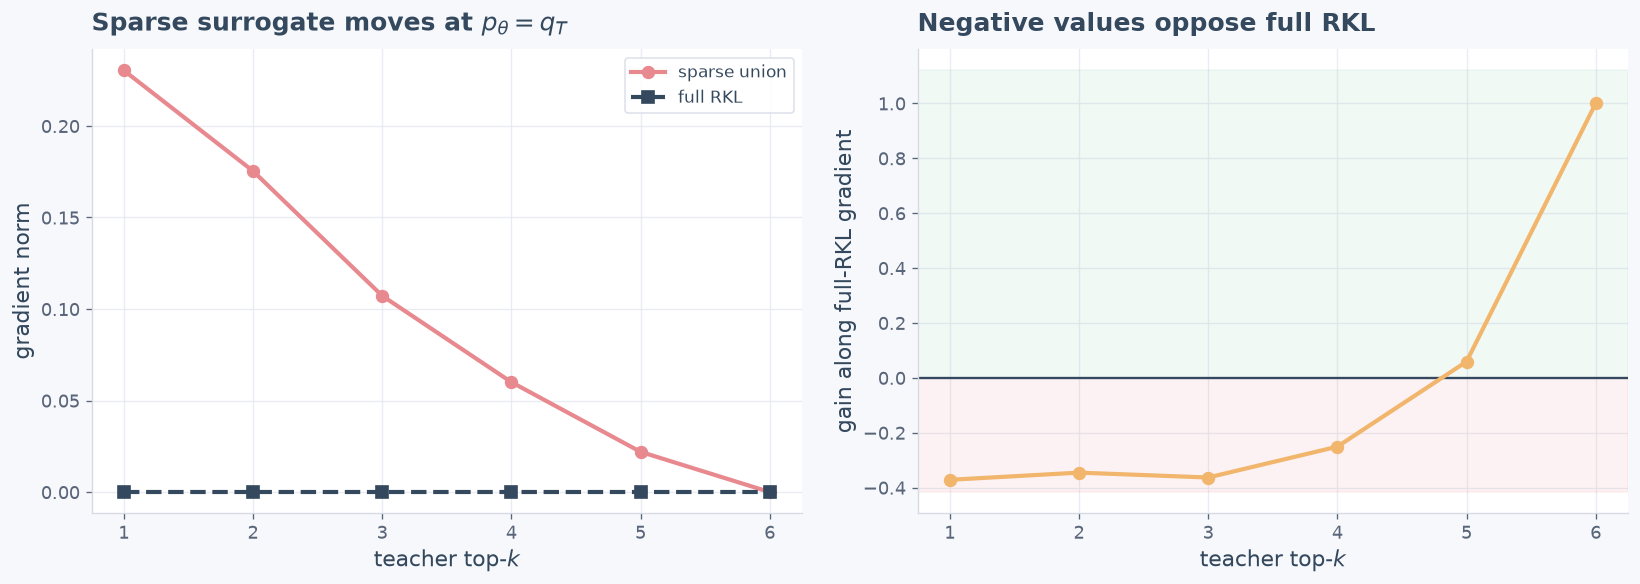

In [11]:
match_rows = teacher_match_k_sweep(verify_prime=False)
ranked_rows = ranked_mode_k_sweep(verify_prime=False)
match_df = pd.DataFrame(compact_comparison_records(match_rows))
ranked_df = pd.DataFrame(compact_comparison_records(ranked_rows))

display(
    match_df[["k", "omitted_p_mass", "full_gradient_norm", "union_gradient_norm", "relation"]]
)
display(
    ranked_df[
        ["k", "omitted_p_mass", "cosine", "directional_gain", "relative_bias", "relation"]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].plot(
    match_df["k"],
    match_df["union_gradient_norm"],
    "o-",
    color=PASTEL["coral"],
    label="sparse union",
)
axes[0].plot(
    match_df["k"],
    match_df["full_gradient_norm"],
    "s--",
    color=PASTEL["ink"],
    label="full RKL",
)
axes[0].set(
    xlabel="teacher top-$k$",
    ylabel="gradient norm",
    title="Sparse surrogate moves at $p_\\theta=q_T$",
)
axes[0].set_xticks(match_df["k"])
axes[0].legend()
axes[1].axhspan(
    ranked_df.directional_gain.min() * 1.12,
    0,
    color=PASTEL["coral"],
    alpha=0.10,
)
axes[1].axhspan(0, ranked_df.directional_gain.max() * 1.12, color=PASTEL["mint"], alpha=0.10)
axes[1].axhline(0, color=PASTEL["ink"], lw=1.4)
axes[1].plot(
    ranked_df["k"],
    ranked_df["directional_gain"],
    "o-",
    color=PASTEL["apricot"],
)
axes[1].set(
    xlabel="teacher top-$k$",
    ylabel="gain along full-RKL gradient",
    title="Negative values oppose full RKL",
)
axes[1].set_xticks(ranked_df["k"])
fig.tight_layout(pad=1.6)
plt.show()

In [12]:
boundary = pd.DataFrame([asdict(row) for row in representative_boundary_rows(verify_prime=False)])
display(
    boundary[
        [
            "omitted_student_mass",
            "tail_log_p_over_q",
            "omitted_modes",
            "full_tail_margin",
            "union_tail_margin",
            "directional_gain",
            "residual_bucket_directional_gain",
            "relation",
        ]
    ]
)

,omitted_student_mass,tail_log_p_over_q,omitted_modes,full_tail_margin,union_tail_margin,directional_gain,residual_bucket_directional_gain,relation
0,0.10,0.0,1,0.00000,-0.90000,NaN,NaN,full-stationary
1,0.01,2.0,1,2.00870,-0.96130,-0.47857,1.0,opposes
2,0.10,2.0,1,2.09173,-0.60827,-0.29079,1.0,opposes
3,0.10,10.0,1,10.10536,0.20536,0.02032,1.0,aligns
4,0.10,10.0,4,10.10536,-0.61964,-0.06132,1.0,opposes
5,0.30,2.0,1,2.31523,0.21523,0.09296,1.0,aligns
6,0.30,2.0,4,2.31523,-0.45977,-0.19859,1.0,opposes


For omitted mass (M), split uniformly across (m) outcomes, let
(\ell_{tail}=\log(p_{tail}/q_{tail})) and
(\ell_{head}=\log(p_{head}/q_{head})).  Full RKL and sparse union
use different sign boundaries:

$$
\text{full: }\ell_{tail}-\ell_{head},
\qquad
\text{union: }\frac{M}{m}(1+\ell_{tail})-(1+\ell_{head}).
$$

Fragmenting fixed omitted mass can flip an aligned update into an opposing
one.  Two controls clarify the trade-off:

- importance weighting the tail by (1/b_y) restores the exact mean but has
  large rare-token variance;
- one residual “other” bucket is deterministic, nonnegative, and stationary
  at (p=q), but cannot learn how mass should be allocated *within* the
  omitted tail.

Scope: this is an exact fixed-context finding about the checked-in sparse
loss.  Action-dependent sequence length, stale/truncated sampling, prefix
occupancy, and shared Transformer parameters change the aggregate LLM
vector field.  They do not turn the local surrogate into a proper KL, but
they can change the magnitude or cancel directions across tokens.

## 5. Capacity stress test — mass, coverage, and peak are different targets

Here we deliberately remove teacher bias by setting
(p^*=q_T=p_{demo}).  The experiment isolates what happens when that common
bimodal truth is projected into a student family capable of only one
Gaussian mode.

We now choose a distribution so the three operators have distinct,
preregistered predictions:

$$
q(x)=0.8\,\mathcal N(-4,1^2)+0.2\,\mathcal N(+4,0.1^2),
$$

while the student is restricted to one Gaussian.

- FKL/SFT must match the first two moments: 
  $\mu=-2.4,\ \sigma^2=11.042$.
- separated-mode RKL should choose the left component because it contains
  more total mass.
- pure RL with utility (U(x)=\log q(x)) should collapse toward the narrow
  right peak because that peak is higher.
- for (J_\alpha=\mathbb E_p\log q+\alpha H(p)), isolated-mode analysis
  predicts a right-to-left switch at $\alpha=0.397940\ldots$.

We enumerate the full two-parameter landscape before looking at optimizer
paths.

In [13]:
study = run_asymmetric_study(
    landscape_config=LandscapeConfig(),
    trajectory_steps=300,
    trajectory_sample_count=2048,
)

minimum_specs = [
    ("SFT / FKL", "sft", None),
    ("OPD / RKL", "opd_rkl", None),
    ("pure RL", "pure_rl", None),
    ("entropy RL α=.35", "entropy_rl", 0.35),
    ("entropy RL α=.41", "entropy_rl", 0.41),
    ("entropy RL α=1", "entropy_rl", 1.0),
]
minimum_rows = []
for label, objective, alpha in minimum_specs:
    point = study.landscape.minimum(objective, alpha=alpha)
    minimum_rows.append(
        {
            "objective": label,
            "mean": point.mean,
            "std": point.std,
            "loss": point.value,
            "search boundary?": point.on_search_boundary,
        }
    )
minimum_df = pd.DataFrame(minimum_rows)
display(minimum_df)

print(
    f"entropy switch: predicted={study.predictions.entropy_switch_alpha:.9f}, "
    f"enumerated={study.numerical_switch_alpha:.9f}"
)

,objective,mean,std,loss,search boundary?
0,SFT / FKL,-2.4,3.33070,7.91806,False
1,OPD / RKL,-4.0,0.99961,0.22314,False
2,pure RL,4.0,0.02000,0.24579,True
3,entropy RL α=.35,4.0,0.05908,0.89379,False
4,entropy RL α=.41,-4.0,0.63652,0.94811,False
5,entropy RL α=1,-4.0,0.99961,0.22314,False


entropy switch: predicted=0.397940009, enumerated=0.397949409


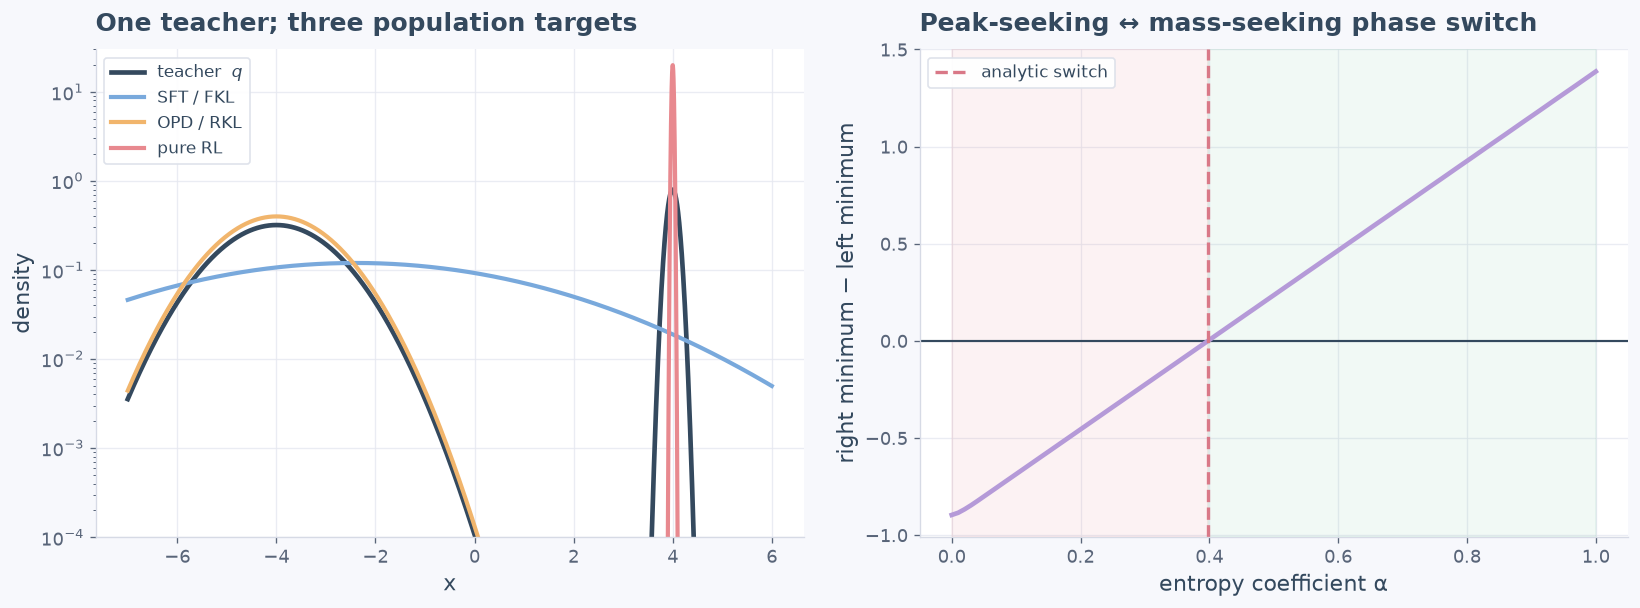

In [14]:
teacher = asymmetric_teacher()
x = np.linspace(-7, 6, 4000)
x_t = torch.as_tensor(x)
teacher_density = teacher.log_prob(x_t).exp().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
axes[0].plot(x, teacher_density, color=PASTEL["ink"], lw=2.8, label="teacher  $q$")
for row, color in zip(
    minimum_rows[:3],
    (PASTEL["blue"], PASTEL["apricot"], PASTEL["coral"]),
    strict=True,
):
    density = np.exp(-0.5 * ((x - row["mean"]) / row["std"]) ** 2) / (
        np.sqrt(2 * np.pi) * row["std"]
    )
    axes[0].plot(x, density, color=color, label=row["objective"])
axes[0].set(xlabel="x", ylabel="density", title="One teacher; three population targets")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-4, 30)
axes[0].legend()

alphas = np.linspace(0, 1, 101)
phase = pd.DataFrame([asdict(row) for row in entropy_phase_sweep(study.landscape, alphas)])
switch_alpha = study.predictions.entropy_switch_alpha
axes[1].axvspan(0, switch_alpha, color=PASTEL["coral"], alpha=0.10)
axes[1].axvspan(switch_alpha, 1, color=PASTEL["mint"], alpha=0.10)
axes[1].axhline(0, color=PASTEL["ink"], lw=1.3)
axes[1].plot(
    phase["alpha"],
    phase["value_gap_right_minus_left"],
    color=PASTEL["lavender"],
    lw=2.8,
)
axes[1].axvline(
    switch_alpha,
    color=PASTEL["rose"],
    ls="--",
    lw=2,
    label="analytic switch",
)
axes[1].set(
    xlabel="entropy coefficient α",
    ylabel="right minimum − left minimum",
    title="Peak-seeking ↔ mass-seeking phase switch",
)
axes[1].legend()
fig.tight_layout(pad=1.6)
plt.show()

The prediction survives numerical integration nearly exactly.  At
$\alpha=1$, entropy-RL is $-\mathbb E_p\log q-H(p)=KL(p\|q)$, so its
landscape and OPD-RKL landscape coincide.  At $\alpha=0$, pure reward
optimization values peak height and drives variance to the lower search
boundary; it is not density matching.

This gives a more precise statement than “forward KL covers and reverse KL
seeks modes”:

- in this separated one-Gaussian bottleneck, FKL projects
  *coverage/moments*;
- in the same bottleneck, RKL chooses a basin by representable component
  *probability mass*;
- with the constructed log-density reward, unregularized RL chooses a
  representable *density peak*;
- entropy continuously changes which of those quantities RL values.

,method,alpha,initial mean,initial std,final mean,final std,left mass,right mass,KL(q||p),KL(p||q),E_p log q
0,sft,0.00,0.0,2.0,-2.39653,3.32395,0.76454,2.35459e-01,1.16097,4.66723,-7.28733
1,opd_rkl,0.00,0.0,2.0,-3.97561,1.00007,0.99996,3.51412e-05,6.22149,0.22344,-1.64245
2,opd_rkl,0.00,4.0,0.1,4.00000,0.10005,0.00000,1.00000e+00,2594.56572,1.60944,-0.72631
3,rl,0.00,0.0,2.0,-3.97238,0.16097,1.00000,0.00000e+00,258.42735,1.56304,-1.15542
4,rl,0.00,-4.0,1.0,-4.00000,0.11432,1.00000,0.00000e+00,517.69160,1.89844,-1.14862
5,rl,0.35,4.0,0.1,4.00000,0.05921,0.00000,1.00000e+00,7413.29106,1.80882,-0.40108
6,rl,0.50,-4.0,1.0,-4.00000,0.70750,1.00000,7.84978e-09,12.70111,0.31944,-1.39236
7,rl,1.00,0.0,2.0,-3.97561,1.00007,0.99996,3.51412e-05,6.22149,0.22344,-1.64245


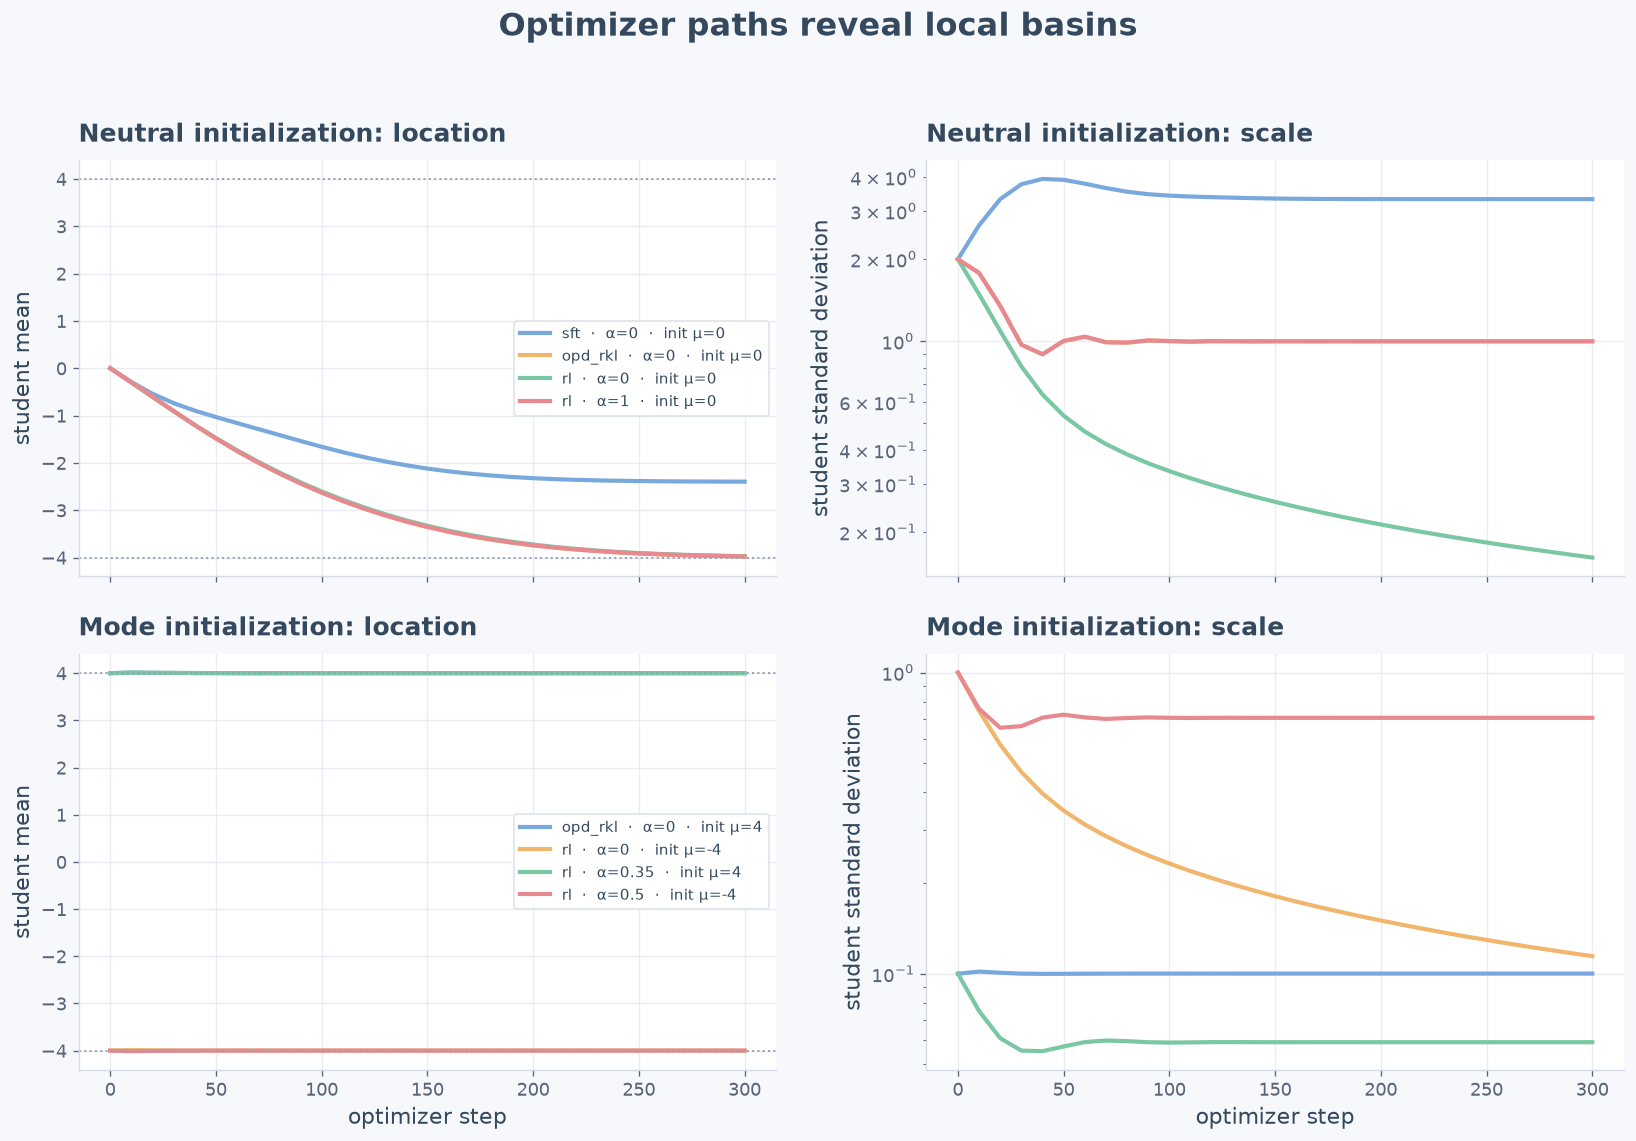

In [15]:
trajectory_rows = []
for trajectory in study.trajectories:
    final = trajectory.final.metrics
    trajectory_rows.append(
        {
            "method": trajectory.method,
            "alpha": trajectory.alpha,
            "initial mean": trajectory.initial_mean,
            "initial std": trajectory.initial_std,
            "final mean": final.mean,
            "final std": final.std,
            "left mass": final.left_mass,
            "right mass": final.right_mass,
            "KL(q||p)": final.kl_teacher_student,
            "KL(p||q)": final.kl_student_teacher,
            "E_p log q": final.expected_log_teacher,
        }
    )
trajectory_df = pd.DataFrame(trajectory_rows)
display(trajectory_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 9.5), sharex="col")
for trajectory in study.trajectories:
    row = 0 if abs(trajectory.initial_mean) < 1e-12 else 1
    label = f"{trajectory.method}  ·  α={trajectory.alpha:g}  ·  init μ={trajectory.initial_mean:g}"
    steps = [point.step for point in trajectory.points]
    means = [point.metrics.mean for point in trajectory.points]
    stds = [point.metrics.std for point in trajectory.points]
    axes[row, 0].plot(steps, means, label=label)
    axes[row, 1].plot(steps, stds, label=label)
for row, row_name in enumerate(("Neutral initialization", "Mode initialization")):
    axes[row, 0].axhline(-4, color=PASTEL["muted"], lw=1.2, ls=":")
    axes[row, 0].axhline(+4, color=PASTEL["muted"], lw=1.2, ls=":")
    axes[row, 0].set(ylabel="student mean", title=f"{row_name}: location")
    axes[row, 1].set(ylabel="student standard deviation", title=f"{row_name}: scale")
    axes[row, 1].set_yscale("log")
    axes[row, 0].legend(fontsize=9)
axes[1, 0].set_xlabel("optimizer step")
axes[1, 1].set_xlabel("optimizer step")
fig.suptitle("Optimizer paths reveal local basins", y=1.01)
fig.tight_layout(pad=1.7)
plt.show()

The optimizer paths add a second distinction.  The exact objective may prefer
one mode while a local update remains in the initialized mode.  In
particular, RKL initialized on the narrow right mode stays there even though
the broad left mode is globally better, and pure RL initialized on the left
collapses locally rather than discovering the taller right peak.  “Which
objective wins?” and “which local basin is reached from this initialization?”
are separate questions.

These paths use deterministic midpoint-quantile samples and the same Adam
learning rate.  They diagnose local basins; they are not evidence about
finite-sample efficiency or a fair behavioral-KL-matched race.

## 6. A shift is not yet a support barrier

This is an information-shape ablation rather than a teacher-bias test.  Each
distillation row treats its displayed shifted teacher as the aligned desired
target; the RL row treats the shifted target interval as the trusted utility
region.  The question is whether the current student receives a usable
direction, not which source defines truth.

A remote target can be difficult for two different reasons.  Compare a
fixed-width Gaussian student centered at zero against teachers shifted by
the same distance (d):

1. a shifted Gaussian teacher has informative log-density slope everywhere;
2. a high-density target interval plus a flat epsilon background is
   directionless outside the interval.

Let (\chi) be the student's probability of the target interval and let
(\chi'=d\chi/d\mu) point toward it.  Before sampling, the location-family
predictions are

$$
u_{RKL}^{Gaussian}=d/\sigma_q^2,
\qquad
u_{RKL}^{flat}=\log(q_{in}/q_{out})\,\chi',
\qquad
u_{RL}^{binary}=\chi'.
$$

The epsilon floor improves flat-teacher OPD only logarithmically, while
(\chi') shrinks essentially exponentially with distance.  SFT/FKL receives
teacher actions or the complete teacher row, so its location signal remains
order (d).  For (N) on-policy samples,

$$
P(\text{at least one target hit})=1-(1-\chi)^N,
$$

with the discoverability transition near (N\chi=1).

In [16]:
shift_study = run_shift_sweep(
    displacements=(2.5, 3.5, 4.5),
    epsilons=(1e-3,),
    seeds=tuple(range(32)),
    config=ShiftConfig(grid_step=0.1),
)

shift_prediction_df = pd.DataFrame([asdict(row) for row in shift_study.predictions])
display(
    shift_prediction_df[
        [
            "teacher_shape",
            "displacement",
            "chi",
            "effective_batch_boundary",
            "sft_toward_signal",
            "opd_toward_signal",
            "sparse_rl_toward_signal",
        ]
    ]
)

,teacher_shape,displacement,chi,effective_batch_boundary,sft_toward_signal,opd_toward_signal,sparse_rl_toward_signal
0,gaussian_tail,2.5,0.02440,40.98314,2.5000,2.50000,0.05573
1,flat_interval,2.5,0.02440,40.98314,2.4975,0.54654,0.05573
2,gaussian_tail,3.5,0.00156,642.20543,3.5000,3.50000,0.00502
3,flat_interval,3.5,0.00156,642.20543,3.4965,0.04921,0.00502
4,gaussian_tail,4.5,0.00004,25913.85089,4.5000,4.50000,0.00016
5,flat_interval,4.5,0.00004,25913.85089,4.4955,0.00158,0.00016


,teacher_shape,method,displacement,epsilon,chi,raw_toward_signal,mean_delta_toward,realized_kl
0,gaussian_tail,sft,2.5,NaN,0.02440,2.50000,0.03162,0.0005
1,gaussian_tail,opd_rkl,2.5,NaN,0.02440,2.50000,0.03162,0.0005
2,gaussian_tail,opd_fkl,2.5,NaN,0.02440,2.50000,0.03162,0.0005
3,flat_interval,sft,2.5,0.001,0.02440,2.49750,0.03162,0.0005
4,flat_interval,opd_rkl,2.5,0.001,0.02440,0.54654,0.03162,0.0005
5,flat_interval,opd_fkl,2.5,0.001,0.02440,2.49750,0.03162,0.0005
6,sparse_reward,rl,2.5,NaN,0.02440,0.05573,0.03162,0.0005
7,gaussian_tail,sft,3.5,NaN,0.00156,3.50000,0.03162,0.0005
8,gaussian_tail,opd_rkl,3.5,NaN,0.00156,3.50000,0.03162,0.0005
9,gaussian_tail,opd_fkl,3.5,NaN,0.00156,3.50000,0.03162,0.0005


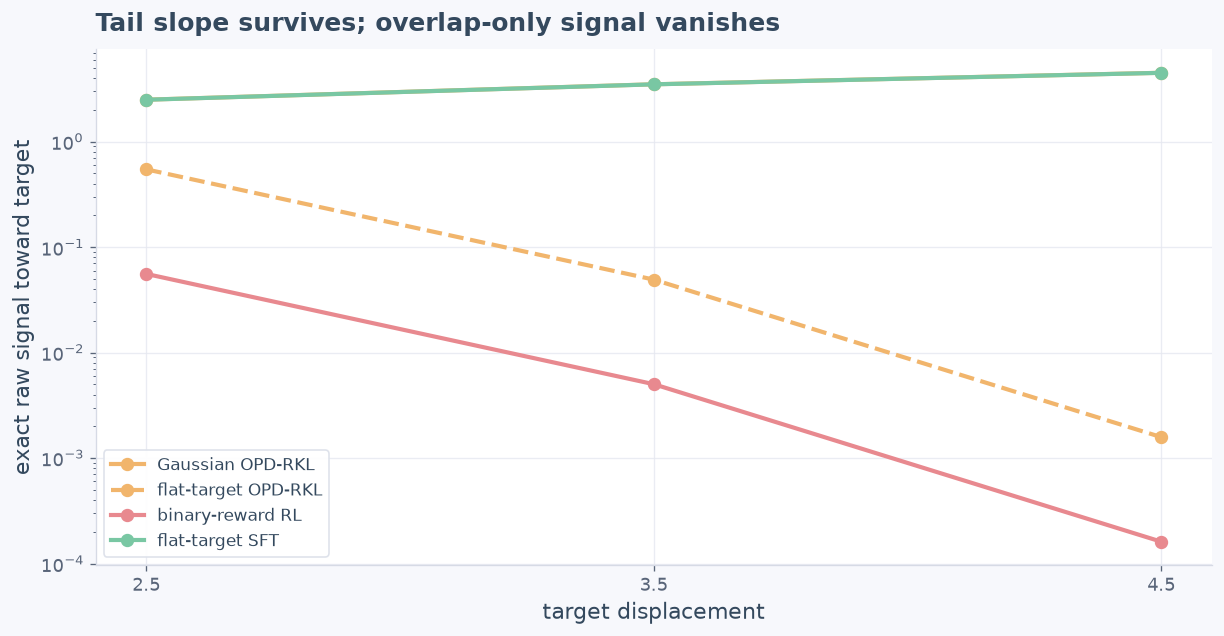

In [17]:
exact_shift_df = pd.DataFrame([asdict(row) for row in shift_study.exact_updates])
display(
    exact_shift_df[
        [
            "teacher_shape",
            "method",
            "displacement",
            "epsilon",
            "chi",
            "raw_toward_signal",
            "mean_delta_toward",
            "realized_kl",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(10.5, 5.6))
signal_curves = (
    (
        "Gaussian OPD-RKL",
        (exact_shift_df.teacher_shape == "gaussian_tail") & (exact_shift_df.method == "opd_rkl"),
        PASTEL["apricot"],
        "-",
    ),
    (
        "flat-target OPD-RKL",
        (exact_shift_df.teacher_shape == "flat_interval") & (exact_shift_df.method == "opd_rkl"),
        PASTEL["apricot"],
        "--",
    ),
    (
        "binary-reward RL",
        (exact_shift_df.teacher_shape == "sparse_reward") & (exact_shift_df.method == "rl"),
        PASTEL["coral"],
        "-",
    ),
    (
        "flat-target SFT",
        (exact_shift_df.teacher_shape == "flat_interval") & (exact_shift_df.method == "sft"),
        PASTEL["mint"],
        "-",
    ),
)
for label, selector, color, line_style in signal_curves:
    curve = exact_shift_df[selector].sort_values("displacement")
    ax.plot(
        curve.displacement,
        curve.raw_toward_signal,
        marker="o",
        ls=line_style,
        color=color,
        label=label,
    )
ax.set_yscale("log")
ax.set(
    xlabel="target displacement",
    ylabel="exact raw signal toward target",
    title="Tail slope survives; overlap-only signal vanishes",
)
ax.set_xticks(sorted(exact_shift_df.displacement.unique()))
ax.legend()
fig.tight_layout(pad=1.5)
plt.show()

In [18]:
shift_compact_df = pd.DataFrame(compact_update_rows(shift_study))
far_sampled = shift_compact_df[
    (shift_compact_df.estimator == "sampled")
    & (shift_compact_df.displacement == 4.5)
    & (
        ((shift_compact_df.teacher == "gaussian_tail") & (shift_compact_df.method == "opd_rkl"))
        | ((shift_compact_df.teacher == "flat_interval") & (shift_compact_df.method == "opd_rkl"))
        | ((shift_compact_df.teacher == "sparse_reward") & (shift_compact_df.method == "rl"))
    )
].copy()


def wilson_95(rate: float, trials: int) -> tuple[float, float]:
    z = 1.959963984540054
    denominator = 1.0 + z**2 / trials
    center = (rate + z**2 / (2.0 * trials)) / denominator
    half_width = z * np.sqrt(rate * (1.0 - rate) / trials + z**2 / (4.0 * trials**2)) / denominator
    return center - half_width, center + half_width


far_sampled["predicted_hit_se"] = np.sqrt(
    far_sampled.p_discovery * (1.0 - far_sampled.p_discovery) / far_sampled.seeds
)
far_sampled["hit_95_ci"] = [
    wilson_95(rate, int(trials)) for rate, trials in zip(far_sampled.hit_rate, far_sampled.seeds, strict=True)
]
far_sampled["toward_95_ci"] = [
    wilson_95(rate, int(trials))
    for rate, trials in zip(far_sampled.toward_rate, far_sampled.seeds, strict=True)
]
display(
    far_sampled[
        [
            "teacher",
            "method",
            "N",
            "seeds",
            "chi",
            "N_chi",
            "p_discovery",
            "predicted_hit_se",
            "hit_rate",
            "hit_95_ci",
            "toward_rate",
            "toward_95_ci",
            "mean_raw_toward_signal",
            "matched_rate",
            "sample_regimes",
        ]
    ]
)

bridge_df = pd.DataFrame([asdict(row) for row in shift_study.bridge_plans])
display(bridge_df[bridge_df.displacement == 4.5])

,teacher,method,N,seeds,chi,N_chi,p_discovery,predicted_hit_se,hit_rate,hit_95_ci,toward_rate,toward_95_ci,mean_raw_toward_signal,matched_rate,sample_regimes
42,gaussian_tail,opd_rkl,8192.0,32,0.00004,0.31612,0.27104,0.07858,0.250,"(0.1325240091850904, 0.4210655899424448)",1.00000,"(0.8928208017449293, 1.0)",4.50641,1.000,discovery_hit:8;tail_signal_no_hit:24
44,flat_interval,opd_rkl,8192.0,32,0.00004,0.31612,0.27104,0.07858,0.250,"(0.1325240091850904, 0.4210655899424448)",0.43750,"(0.2816533111504036, 0.6067440886314801)",-0.00419,1.000,discovery_hit:8;score_noise_no_hit:24
45,sparse_reward,rl,8192.0,32,0.00004,0.31612,0.27104,0.07858,0.250,"(0.1325240091850904, 0.4210655899424448)",0.25000,"(0.1325240091850904, 0.4210655899424448)",0.00017,0.250,discovery_hit:8;zero_gradient_no_hit:24
47,gaussian_tail,opd_rkl,32768.0,32,0.00004,1.26450,0.71763,0.07958,0.875,"(0.7193169451834978, 0.9502986561251991)",1.00000,"(0.8928208017449293, 1.0)",4.49277,1.000,discovery_hit:28;tail_signal_no_hit:4
49,flat_interval,opd_rkl,32768.0,32,0.00004,1.26450,0.71763,0.07958,0.875,"(0.7193169451834978, 0.9502986561251991)",0.53125,"(0.3644951711897464, 0.6913061289193116)",-0.00112,1.000,discovery_hit:28;score_noise_no_hit:4
50,sparse_reward,rl,32768.0,32,0.00004,1.26450,0.71763,0.07958,0.875,"(0.7193169451834978, 0.9502986561251991)",0.87500,"(0.7193169451834978, 0.9502986561251991)",0.00022,0.875,discovery_hit:28;zero_gradient_no_hit:4


,displacement,batch_size,direct_chi,direct_n_chi,direct_discovery_probability,max_discoverable_stage_shift,stage_count,stage_centers
4,4.5,8192,0.00004,0.31612,0.27104,4.2,2,"(4.2, 4.5)"
5,4.5,32768,0.00004,1.26450,0.71763,4.5,1,"(4.5,)"


The exact and sampled views agree on the mechanism:

- Gaussian-tail OPD usually points correctly even in a zero-hit batch because
  every sampled log-density contains distance information.
- Flat-target OPD has only score noise in a zero-hit batch; sparse binary RL
  has exactly zero gradient when every reward is equal.
- SFT/FKL still sees the remote target directly.

Every nonzero exact gradient above was also scaled to the same one-step
behavioral KL.  That makes its mean movement almost identical and thereby
demonstrates why matched-KL movement alone is insufficient: it conditions
away the probability of obtaining a useful direction.  We must report raw
signal, hit probability, and failed/no-op updates too.

The bridge table is deliberately only a reachability calculation.  It says
how many idealized recentering stages keep (N\chi\ge1); it assumes each stage
succeeds and is not yet evidence that a trained curriculum converges.

## 7. State occupancy, KL direction, and teacher reliability

A one-state distribution cannot test the claimed benefit of student-prefix
distillation.  The smallest valid sequential model has one frozen first
action selecting two second-step states:

$$
d_q=(1,0),\qquad d_p=(0.2,0.8).
$$

The second row is therefore a student recovery state absent from teacher
demonstrations.  Its policy is a fully expressive three-action categorical,
so capacity is no longer a confound.  On that recovery row the desired
distribution (p^*) puts its largest mass on the “good” action; teacher
reliability explicitly interpolates (q_T) toward or away from that desired
conditional.  We factorially cross

- teacher-state versus student-state collection, and
- hard teacher labels, full-logit FKL, and sampled-action RKL.

The latter two are both “OPD” when their states come from the student, but
they have different action information.  Hard labels at student states are a
matched estimator control—not ordinary offline SFT, whose state collector is
the demonstration occupancy.

In [19]:
two_step = run_two_step_study(
    finite_seeds=tuple(range(32)),
    sparse_seeds=tuple(range(128)),
)
display(pd.DataFrame([asdict(two_step.predictions)]).T.rename(columns={0: "preregistered prediction"}))

,preregistered prediction
population_target,"On every state with positive collector mass, h..."
coverage_prediction,A zero-mass recovery state has exactly zero up...
finite_variance_prediction,FKL has only state-count noise; hard SFT also ...
reliability_prediction,At the population endpoint on the recovery sta...
initial_update_prediction,"For this three-action fork, every method initi..."
hard_label_information,One teacher-sampled action label per queried s...
fkl_information,The complete teacher probability row q(a|s) pe...
rkl_information,A student-sampled action plus the teacher log-...
top_action_agreement_threshold,0.5
recovery_improvement_threshold,0.17647


,reliability,collector,method,identified_states,endpoint recovery p(good),one-step recovery p(good),matched_expected_utility,matched_kl
0,0.00,teacher,sft_hard,"(True, False)",0.2000,0.20000,0.21478,0.01000
1,0.00,teacher,opd_fkl,"(True, False)",0.2000,0.20000,0.21478,0.01000
2,0.00,teacher,opd_rkl,"(True, False)",0.2000,0.20000,0.21272,0.00999
3,0.00,student,sft_hard,"(True, True)",0.0500,0.21514,0.20516,0.01003
4,0.00,student,opd_fkl,"(True, True)",0.0500,0.21514,0.20516,0.01003
5,0.00,student,opd_rkl,"(True, True)",0.0500,0.23658,0.22257,0.01001
6,0.25,teacher,sft_hard,"(True, False)",0.2000,0.20000,0.21478,0.01000
7,0.25,teacher,opd_fkl,"(True, False)",0.2000,0.20000,0.21478,0.01000
8,0.25,teacher,opd_rkl,"(True, False)",0.2000,0.20000,0.21272,0.00999
9,0.25,student,sft_hard,"(True, True)",0.2625,0.23144,0.21839,0.01004


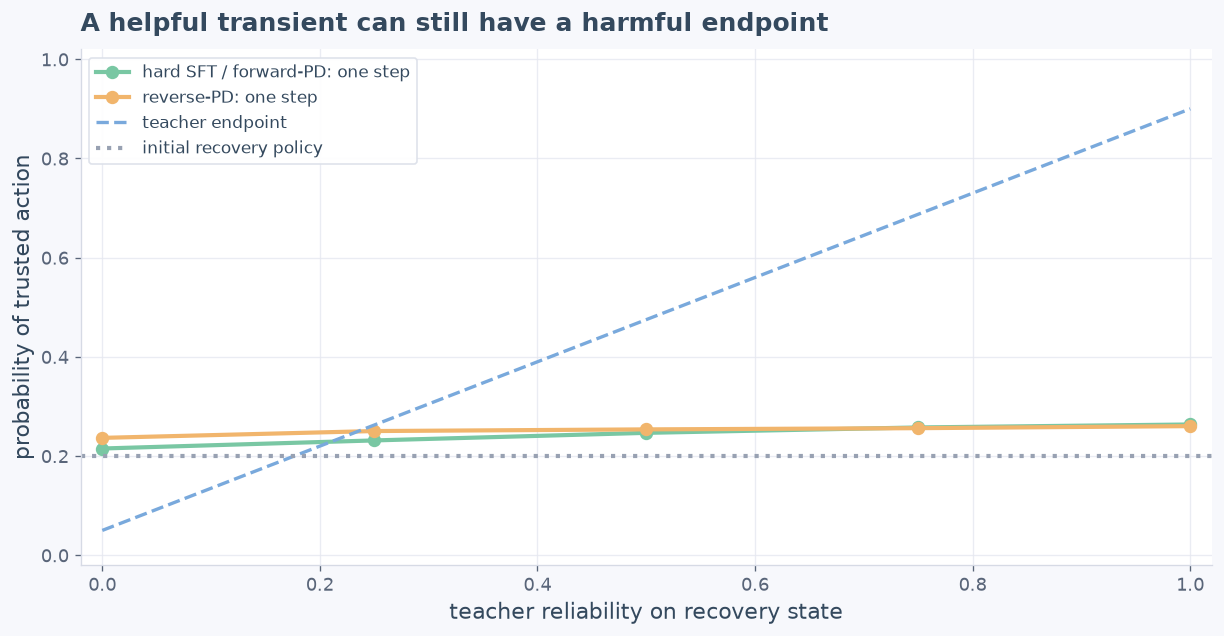

In [20]:
two_exact_df = pd.DataFrame([asdict(row) for row in two_step.exact])
two_exact_df["endpoint recovery p(good)"] = two_exact_df.canonical_recovery_probs.map(lambda row: row[1])
two_exact_df["one-step recovery p(good)"] = two_exact_df.matched_recovery_probs.map(lambda row: row[1])
display(
    two_exact_df[
        [
            "reliability",
            "collector",
            "method",
            "identified_states",
            "endpoint recovery p(good)",
            "one-step recovery p(good)",
            "matched_expected_utility",
            "matched_kl",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(10.5, 5.6))
student_exact = two_exact_df[two_exact_df.collector == "student"]
sft_recovery = student_exact[student_exact.method == "sft_hard"].sort_values("reliability")
fkl_recovery = student_exact[student_exact.method == "opd_fkl"].sort_values("reliability")
assert np.allclose(
    sft_recovery["one-step recovery p(good)"],
    fkl_recovery["one-step recovery p(good)"],
    atol=1e-12,
    rtol=0.0,
)
two_method_labels = {
    "opd_fkl": "hard SFT / forward-PD",
    "opd_rkl": "reverse-PD",
}
two_method_colors = {"opd_fkl": PASTEL["mint"], "opd_rkl": PASTEL["apricot"]}
for method, group in student_exact[student_exact.method != "sft_hard"].groupby("method"):
    group = group.sort_values("reliability")
    ax.plot(
        group.reliability,
        group["one-step recovery p(good)"],
        "o-",
        color=two_method_colors[method],
        label=f"{two_method_labels[method]}: one step",
    )
endpoint = student_exact[student_exact.method == "opd_fkl"].sort_values("reliability")
ax.plot(
    endpoint.reliability,
    endpoint["endpoint recovery p(good)"],
    "--",
    color=PASTEL["blue"],
    lw=2,
    label="teacher endpoint",
)
ax.axhline(0.2, color=PASTEL["muted"], ls=":", label="initial recovery policy")
ax.set(
    xlabel="teacher reliability on recovery state",
    ylabel="probability of trusted action",
    title="A helpful transient can still have a harmful endpoint",
    xlim=(-0.02, 1.02),
    ylim=(-0.02, 1.02),
)
ax.legend()
fig.tight_layout(pad=1.5)
plt.show()

In [21]:
two_finite_df = pd.DataFrame([asdict(row) for row in two_step.finite])
display(
    two_finite_df[
        two_finite_df.reliability.isin((0.0, 1.0)) & (two_finite_df.query_count == 64)
    ][
        [
            "reliability",
            "collector",
            "method",
            "query_count",
            "seeds",
            "recovery_seen_rate",
            "update_rate",
            "mean_recovery_trusted_probability",
            "std_recovery_trusted_probability",
            "mean_expected_trusted_utility",
        ]
    ]
)

sparse_rl_df = pd.DataFrame([asdict(row) for row in two_step.sparse_rl])
sparse_summary_df = (
    sparse_rl_df.groupby(["group_count", "group_size"], as_index=False)
    .agg(
        predicted_update_rate=("predicted_batch_informative_probability", "first"),
        empirical_update_rate=("step_bracketed", "mean"),
        mean_jackpot_samples=("jackpot_samples", "mean"),
        mean_probability_after=("jackpot_probability_after_update", "mean"),
    )
)
display(sparse_summary_df)

,reliability,collector,method,query_count,seeds,recovery_seen_rate,update_rate,mean_recovery_trusted_probability,std_recovery_trusted_probability,mean_expected_trusted_utility
2,0.0,student,opd_fkl,64,32,1.0,1.0,0.21510,0.00008,0.20526
5,0.0,student,opd_rkl,64,32,1.0,1.0,0.23621,0.00575,0.22260
8,0.0,student,sft_hard,64,32,1.0,1.0,0.21554,0.00216,0.20569
11,0.0,teacher,opd_fkl,64,32,0.0,1.0,0.20000,0.00000,0.21478
14,0.0,teacher,opd_rkl,64,32,0.0,1.0,0.20000,0.00000,0.21286
17,0.0,teacher,sft_hard,64,32,0.0,1.0,0.20000,0.00000,0.21473
74,1.0,student,opd_fkl,64,32,1.0,1.0,0.26343,0.00028,0.24342
77,1.0,student,opd_rkl,64,32,1.0,1.0,0.26024,0.00055,0.24033
80,1.0,student,sft_hard,64,32,1.0,1.0,0.26338,0.00057,0.24345
83,1.0,teacher,opd_fkl,64,32,0.0,1.0,0.20000,0.00000,0.21478


,group_count,group_size,predicted_update_rate,empirical_update_rate,mean_jackpot_samples,mean_probability_after
0,1,8,0.07726,0.07812,0.07812,0.01120
1,4,8,0.27502,0.32031,0.35156,0.01517
2,16,8,0.72375,0.71094,1.24219,0.02219
3,64,8,0.99418,1.00000,5.30469,0.02959


The factorial result is exact: changing RKL to FKL does not repair a missing
state.  Under teacher collection the recovery row has zero gradient for all
three estimators; under student collection it is identified by all three.
On a covered tabular row every distillation method converges to the teacher,
even when that teacher is wrong.

Reliability also separates a transient from a target.  Here an unreliable
teacher initially removes a dominant distractor, so trusted-action mass can
rise for one step even though convergence eventually lowers it.  Short-run
reward improvement is not proof that the distillation target is safe.

The final table removes state discovery and tests sparse action discovery
alone.  Prime-like centered group rewards update only when at least one group
contains reward contrast.  For reward-class masses (c_v), group size (G),
and (M) groups, the predicted update probability is

$$
1-\left(\sum_v c_v^G\right)^M.
$$

This is the precise sense in which RL can have the right target but no
sampled direction.

## 8. Teacher as explorer, reward as selector

The remaining target mismatch needs no extra capacity or state complexity.
Use a fully expressive three-action student with actions
(neutral, desirable, harmful):

$$
p_{init}=(1-2\epsilon,\epsilon,\epsilon),\qquad
q=(0.60,0.35,0.05),\qquad
p^*=(0,1,0),\qquad U^*=(0,+1,-1).
$$

Distillation has the strong support-acquisition target (q), but necessarily
copies the teacher's harmful 0.05 mass.  Pure RL has the correct selector
endpoint—the desirable vertex—but initially has only order-epsilon signal.
For distinct reward values, group size (G), and (B) groups,

$$
\pi_{group}=1-\sum_a p(a)^G,
\qquad
\pi_{batch}=1-\left(\sum_a p(a)^G\right)^B.
$$

The default (\epsilon=5\times10^{-4}) is chosen before sampling so that
(60\pi_{batch}=1.89): pure RL lies in the nontrivial order-one discovery
regime rather than an always-impossible or always-easy regime.

A curriculum queries the teacher only until the *current-policy analytic*
(\pi_{batch}) crosses 0.9, then uses RL for every remaining update.  In an
LLM experiment this quantity would be estimated with uncertainty; here the
three probabilities are exactly observable.

In [22]:
curriculum_problem = make_target_problem()
curriculum_config = RunConfig()
curriculum = run_scale_comparison(
    seeds=tuple(range(8)),
    problem=curriculum_problem,
    config=curriculum_config,
)

curriculum_predictions = curriculum.fixed_scale.predictions
gradient_spec = curriculum_predictions.initial_gradients
gradient_df = pd.DataFrame(
    [
        {"operator": "SFT / FKL", "direction": gradient_spec.sft_fkl},
        {"operator": "OPD / RKL", "direction": gradient_spec.opd_rkl},
        {"operator": "pure RL", "direction": gradient_spec.rl},
        {"operator": "grouped RL", "direction": gradient_spec.grouped_rl},
    ]
)
gradient_df["gradient norm"] = gradient_df.direction.map(lambda row: np.linalg.norm(row))

target_df = pd.DataFrame(
    [
        {
            "distribution": "initial student",
            "probabilities": curriculum_predictions.initial_probs,
            "trusted utility": curriculum_predictions.initial_expected_utility,
        },
        {
            "distribution": "distillation endpoint",
            "probabilities": curriculum_predictions.teacher_optimum,
            "trusted utility": curriculum_predictions.teacher_expected_utility,
        },
        {
            "distribution": "pure-RL endpoint",
            "probabilities": curriculum_predictions.rl_optimum,
            "trusted utility": 1.0,
        },
    ]
)
display(target_df)
display(gradient_df)
print(
    f"initial P(informative group)={curriculum_predictions.initial_group_informative_probability:.6f}, "
    f"P(informative batch)={curriculum_predictions.initial_batch_informative_probability:.6f}, "
    f"expected informative batches in budget="
    f"{curriculum_config.total_updates * curriculum_predictions.initial_batch_informative_probability:.3f}"
)

,distribution,probabilities,trusted utility
0,initial student,"(0.999, 0.0005, 0.0005)",0.0
1,distillation endpoint,"(0.6, 0.35, 0.05)",0.3
2,pure-RL endpoint,"(0.0, 1.0, 0.0)",1.0


,operator,direction,gradient norm
0,SFT / FKL,"(-0.3989999999999999, 0.3495, 0.0495)",0.53273
1,OPD / RKL,"(-0.006081862433564557, 0.0035274087540459326,...",0.00748
2,pure RL,"(0.0, 0.0005000000000000001, -0.00050000000000...",0.00071
3,grouped RL,"(0.0, 0.0003750000000000001, -0.00037500000000...",0.00053


initial P(informative group)=0.003994, P(informative batch)=0.031509, expected informative batches in budget=1.891


There are two fair questions, and they must not be merged:

1. **fixed common scale:** preserve raw signal magnitude to ask about progress
   per fixed batch/call budget;
2. **KL matched:** amplify every nonzero direction to the same behavioral KL
   to ask where it points, conditional on having obtained it.

The second view is not a call-efficiency comparison: a vanishing gradient may
require an enormous multiplier.  Homogeneous RL batches remain honest no-ops
in both views.

The eight seeded paths below are an illustrative finite-budget check, not a
high-precision benchmark; their min/max are shown.  The gradient scaling,
no-op probability, and switch condition themselves are exact.

In [23]:
fixed_curriculum_df = pd.DataFrame(curriculum.fixed_scale.summary_records())
matched_curriculum_df = pd.DataFrame(curriculum.kl_matched.summary_records())
for frame in (fixed_curriculum_df, matched_curriculum_df):
    frame["rl_no_op_fraction"] = frame.no_op_updates / frame.rl_updates.replace(0, np.nan)


def summarize_curricula(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby("schedule", as_index=False)
        .agg(
            seeds=("seed", "nunique"),
            median_switch=("switch_update", "median"),
            mean_rl_no_op_fraction=("rl_no_op_fraction", "mean"),
            mean_final_desirable=("final_desirable_probability", "mean"),
            mean_final_harmful=("final_harmful_probability", "mean"),
            median_final_utility=("final_expected_utility", "median"),
            min_final_utility=("final_expected_utility", "min"),
            max_final_utility=("final_expected_utility", "max"),
            mean_teacher_labels=("cost_teacher_hard_labels", "mean"),
            mean_teacher_logps=("cost_teacher_logprob_evals", "mean"),
            mean_full_vectors=("cost_teacher_full_vectors", "mean"),
            mean_rollouts=("cost_student_rollouts", "mean"),
            mean_reward_calls=("cost_reward_calls", "mean"),
        )
        .sort_values("schedule")
    )


fixed_curriculum_summary = summarize_curricula(fixed_curriculum_df)
matched_curriculum_summary = summarize_curricula(matched_curriculum_df)
display(fixed_curriculum_summary)
display(
    matched_curriculum_summary[
        [
            "schedule",
            "median_switch",
            "mean_rl_no_op_fraction",
            "mean_final_desirable",
            "mean_final_harmful",
            "median_final_utility",
        ]
    ]
)

,schedule,seeds,median_switch,mean_rl_no_op_fraction,mean_final_desirable,mean_final_harmful,median_final_utility,min_final_utility,max_final_utility,mean_teacher_labels,mean_teacher_logps,mean_full_vectors,mean_rollouts,mean_reward_calls
0,opd_fkl_then_rl,8,7.0,0.17453,0.98255,0.00222,0.98035,0.97848,0.98228,0.0,21.0,7.0,1696.0,1696.0
1,opd_rkl_then_rl,8,NaN,NaN,0.00113,0.00127,0.00002,-0.00109,0.00015,0.0,1920.0,0.0,1920.0,0.0
2,pure_rl,8,0.0,0.96250,0.00050,0.00048,0.00002,0.00000,0.00009,0.0,0.0,0.0,1920.0,1920.0
3,sft_then_rl,8,7.5,0.18806,0.98280,0.00229,0.98115,0.97634,0.98323,236.0,0.0,0.0,1684.0,1684.0


,schedule,median_switch,mean_rl_no_op_fraction,mean_final_desirable,mean_final_harmful,median_final_utility
0,opd_fkl_then_rl,8.0,0.22837,0.99698,0.00059,0.99683
1,opd_rkl_then_rl,8.0,0.13942,0.99259,0.00155,0.99386
2,pure_rl,0.0,0.81667,0.21071,0.00061,0.00058
3,sft_then_rl,8.0,0.22115,0.99710,0.00046,0.99745


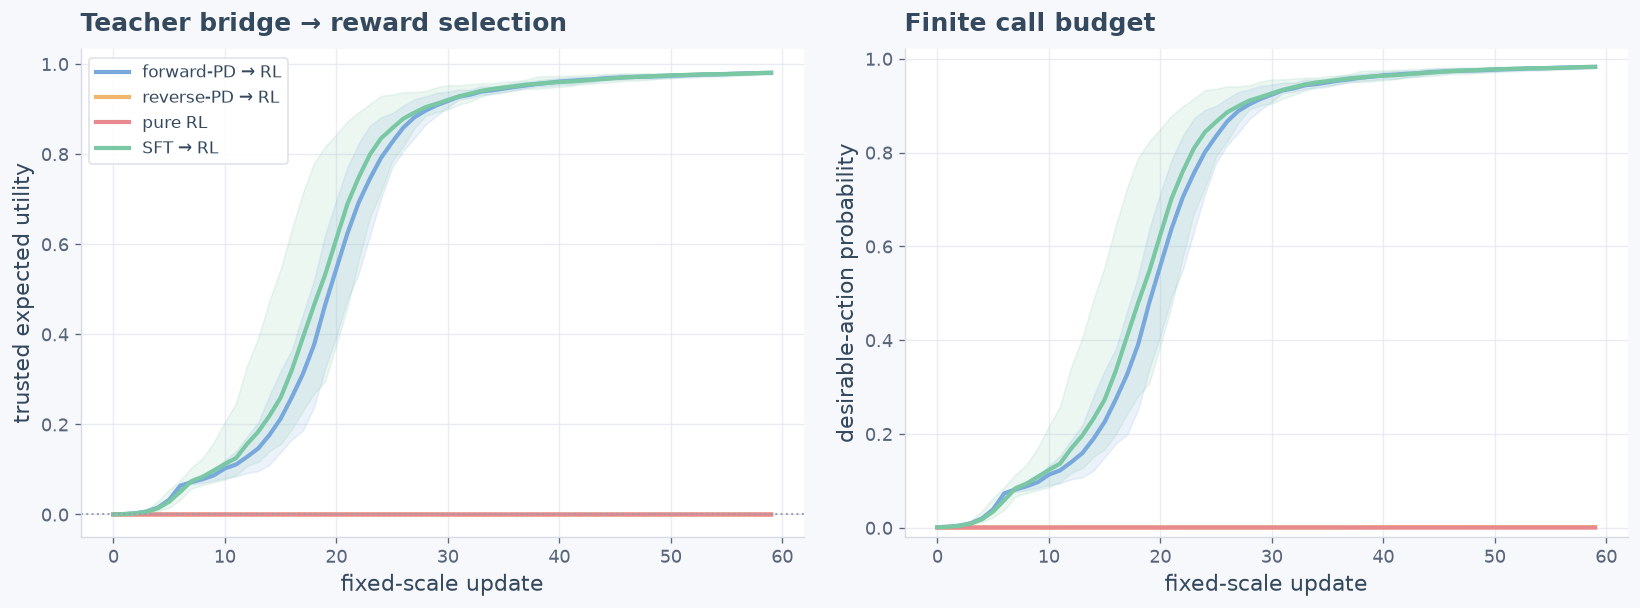

,schedule,raw_grad_norm,applied_step_scale,realized_kl,no_op
480,sft_then_rl,0.55265,2.31543,0.002,False
960,opd_rkl_then_rl,0.00062,1970.00000,0.002,False


In [24]:
fixed_trajectory_df = pd.DataFrame(curriculum.fixed_scale.trajectory_records())
matched_trajectory_df = pd.DataFrame(curriculum.kl_matched.trajectory_records())
mean_fixed_trajectory = (
    fixed_trajectory_df.groupby(["schedule", "update"], as_index=False)
    .agg(
        expected_utility_mean=("expected_utility", "mean"),
        expected_utility_min=("expected_utility", "min"),
        expected_utility_max=("expected_utility", "max"),
        desirable_probability_mean=("desirable_probability", "mean"),
        desirable_probability_min=("desirable_probability", "min"),
        desirable_probability_max=("desirable_probability", "max"),
    )
)

curriculum_labels = {
    "sft_then_rl": "SFT → RL",
    "opd_fkl_then_rl": "forward-PD → RL",
    "opd_rkl_then_rl": "reverse-PD → RL",
    "pure_rl": "pure RL",
}
curriculum_colors = {
    "sft_then_rl": PASTEL["mint"],
    "opd_fkl_then_rl": PASTEL["blue"],
    "opd_rkl_then_rl": PASTEL["apricot"],
    "pure_rl": PASTEL["coral"],
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for schedule, group in mean_fixed_trajectory.groupby("schedule"):
    color = curriculum_colors[schedule]
    label = curriculum_labels[schedule]
    axes[0].plot(group["update"], group.expected_utility_mean, color=color, label=label)
    axes[0].fill_between(
        group["update"],
        group.expected_utility_min,
        group.expected_utility_max,
        color=color,
        alpha=0.14,
    )
    axes[1].plot(group["update"], group.desirable_probability_mean, color=color, label=label)
    axes[1].fill_between(
        group["update"],
        group.desirable_probability_min,
        group.desirable_probability_max,
        color=color,
        alpha=0.14,
    )
axes[0].axhline(0.0, color=PASTEL["muted"], lw=1.2, ls=":")
axes[0].set(xlabel="fixed-scale update", ylabel="trusted expected utility", title="Teacher bridge → reward selection")
axes[1].set(
    xlabel="fixed-scale update",
    ylabel="desirable-action probability",
    title="Finite call budget",
    ylim=(-0.02, 1.02),
)
axes[0].legend()
fig.tight_layout(pad=1.6)
plt.show()

amplification_df = matched_trajectory_df[
    (matched_trajectory_df.seed == 0)
    & (matched_trajectory_df["update"] == 0)
    & matched_trajectory_df.schedule.isin(("sft_then_rl", "opd_rkl_then_rl"))
][
    [
        "schedule",
        "raw_grad_norm",
        "applied_step_scale",
        "realized_kl",
        "no_op",
    ]
]
display(amplification_df)

At a fixed data-call scale, SFT and full-logit FKL cross the analytic/oracle
handoff threshold in roughly 6–8 updates, after which RL removes the teacher's harmful
mass and selects the desirable action.  Pure RL spends most early batches on
exactly zero centered advantages.  Sampled RKL-OPD has the right eventual
teacher endpoint but an order-(\epsilon\log(1/\epsilon)) bridge signal and
does not reach the handoff within this budget.

KL matching changes that last observation: RKL reaches the handoff after its
tiny first gradient is multiplied by a scale hundreds of times larger than
SFT's.  This is useful conditional geometry, but not evidence of equal call
efficiency.  The separate cost columns likewise avoid pretending a hard
teacher label, a scalar teacher log-probability, a full teacher vector, and a
reward call have one universal exchange rate.

More generally, for target failure probability (\delta), a bridge is useful
only if it lowers the remaining contrast requirement

$$
M_{min}(p,\delta)=\left\lceil
\frac{\log\delta}{\log(1-\pi_{group}(p))}
\right\rceil
$$

enough to repay its own cost.  A curriculum cannot repair a wrong final
reward objective.  At a boundary zero that the parameterization can reopen,
demonstrations, full-logit feedback, or explicit exploration may supply the
first direction.  A structural zero imposed by masking or parameterization
requires support widening/reparameterization; on-policy feedback alone cannot
create an unavailable action.

## 9. Bonus — is RL intrinsically less forgetful?

A minimal shared-parameter model can answer the null question exactly.  Use
a binary logistic student

$$
p_\theta(a=1\mid x)=\sigma(\theta^\top x),
$$

with an old context (x_o=(1,0)) and new context
(x_n=(\rho,\sqrt{1-\rho^2})).  The old task is already learned; the new
target conflicts with it.  Every new-context objective has a rank-one
gradient parallel to (x_n), hence

$$
\Delta z_{old}=\rho\,\Delta z_{new}.
$$

The sweep includes SFT, FKL, RKL, pure RL that rewards action zero, and a
calibrated fixed-reference RL control whose Boltzmann endpoint equals the
distillation teacher.  We first use the same raw learning rate—the comparison
that often motivates a forgetting claim—then match either new-task gain or
new-context behavioral KL.

In [25]:
retention = run_retention_study()
retention_definitions_df = pd.DataFrame([asdict(row) for row in retention.method_definitions])
display(retention_definitions_df)

raw_retention_df = pd.DataFrame(compact_retention_rows(retention, regime="raw_step"))
gain_retention_df = pd.DataFrame(compact_retention_rows(retention, regime="matched_new_gain"))
kl_retention_df = pd.DataFrame(compact_retention_rows(retention, regime="matched_behavior_kl"))

display(
    raw_retention_df[raw_retention_df.rho == 1.0][
        [
            "method",
            "raw_gradient_norm",
            "new_positive_before",
            "new_target_gain",
            "new_behavior_kl",
            "old_target_kl_increase",
            "old_positive_drop",
        ]
    ]
)
display(
    gain_retention_df[gain_retention_df.rho == 1.0][
        [
            "method",
            "new_target_gain",
            "new_behavior_kl",
            "old_target_kl_increase",
            "old_positive_drop",
            "prediction_residual",
        ]
    ]
)

,method,objective,teacher_positive_prob,utility_action_0,utility_action_1,reference,kl_beta,endpoint_positive_prob
0,sft,E_q[-log p],0.1,NaN,NaN,NaN,0.0,0.1
1,opd_fkl,E_q[-log p] = KL(q || p) + H(q),0.1,NaN,NaN,NaN,0.0,0.1
2,opd_rkl,KL(p || q),0.1,NaN,NaN,NaN,0.0,0.1
3,rl,-E_p[u],NaN,1.00000,0.00000,NaN,0.0,0.0
4,rl_calibrated,-E_p[log q] + KL(p || uniform),0.1,-0.10536,-2.30259,uniform,1.0,0.1


,method,raw_gradient_norm,new_positive_before,new_target_gain,new_behavior_kl,old_target_kl_increase,old_positive_drop
20,sft,0.8000,0.9,0.60439,0.03561,0.03561,0.09826
21,opd_fkl,0.8000,0.9,0.60439,0.03561,0.03561,0.09826
22,opd_rkl,0.3955,0.9,0.30858,0.00782,0.00782,0.04164
23,rl,0.0900,0.9,0.07163,0.00037,0.00037,0.00840
24,rl_calibrated,0.3955,0.9,0.30858,0.00782,0.00782,0.04164


,method,new_target_gain,new_behavior_kl,old_target_kl_increase,old_positive_drop,prediction_residual
20,sft,0.02,0.00003,0.00003,0.00228,0.00000e+00
21,opd_fkl,0.02,0.00003,0.00003,0.00228,0.00000e+00
22,opd_rkl,0.02,0.00003,0.00003,0.00228,-1.11022e-16
23,rl,0.02,0.00003,0.00003,0.00228,0.00000e+00
24,rl_calibrated,0.02,0.00003,0.00003,0.00228,-1.11022e-16


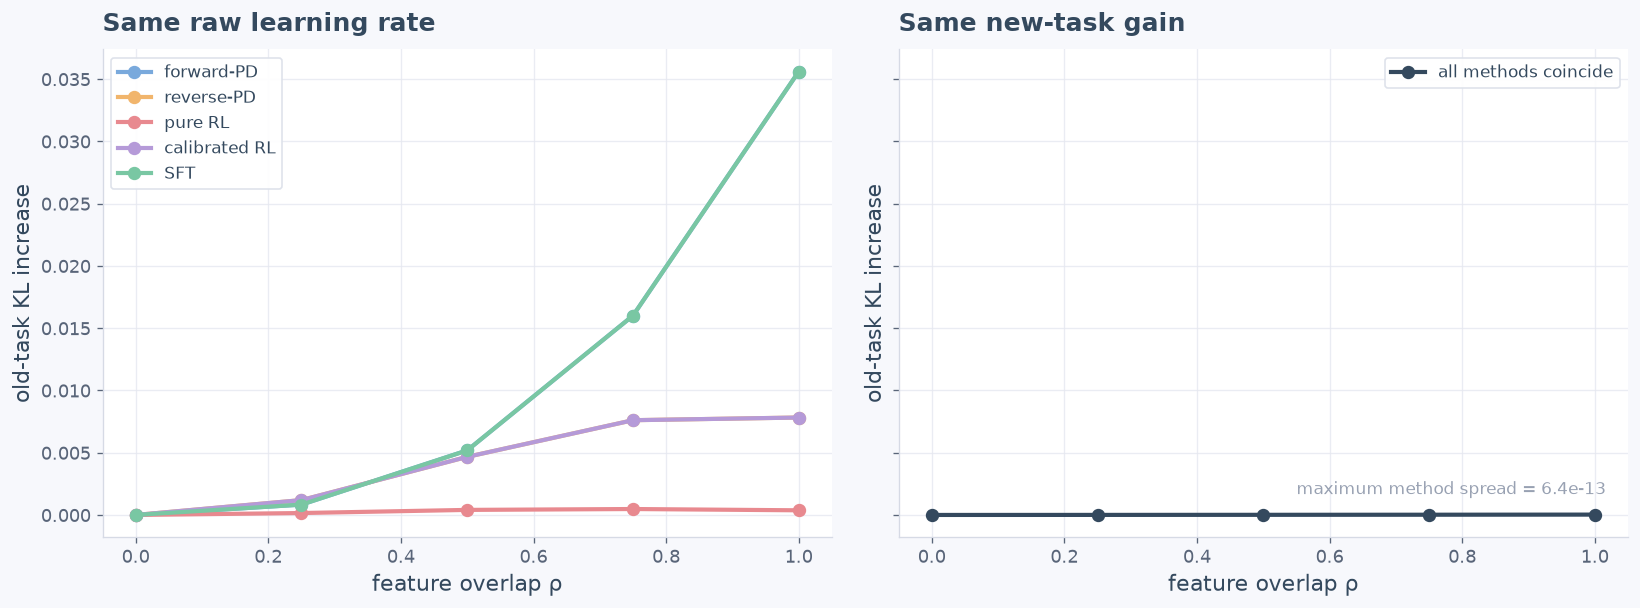

In [26]:
retention_colors = {
    "sft": PASTEL["mint"],
    "opd_fkl": PASTEL["blue"],
    "opd_rkl": PASTEL["apricot"],
    "rl": PASTEL["coral"],
    "rl_calibrated": PASTEL["lavender"],
}
retention_names = {
    "sft": "SFT",
    "opd_fkl": "forward-PD",
    "opd_rkl": "reverse-PD",
    "rl": "pure RL",
    "rl_calibrated": "calibrated RL",
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True)
for method, group in raw_retention_df.groupby("method"):
    group = group.sort_values("rho")
    axes[0].plot(
        group.rho,
        group.old_target_kl_increase,
        "o-",
        color=retention_colors[method],
        label=retention_names[method],
    )
matched_retention = (
    gain_retention_df.groupby("rho")["old_target_kl_increase"]
    .agg(["min", "mean", "max"])
    .reset_index()
)
axes[1].plot(
    matched_retention.rho,
    matched_retention["mean"],
    "o-",
    color=PASTEL["ink"],
    label="all methods coincide",
)
axes[1].fill_between(
    matched_retention.rho,
    matched_retention["min"],
    matched_retention["max"],
    color=PASTEL["lavender"],
    alpha=0.22,
)
maximum_matched_spread = float(
    (matched_retention["max"] - matched_retention["min"]).max()
)
axes[1].text(
    0.97,
    0.08,
    f"maximum method spread = {maximum_matched_spread:.1e}",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
    color=PASTEL["muted"],
    fontsize=10,
)
axes[0].set(title="Same raw learning rate", xlabel="feature overlap ρ", ylabel="old-task KL increase")
axes[1].set(title="Same new-task gain", xlabel="feature overlap ρ", ylabel="old-task KL increase")
axes[0].legend()
axes[1].legend()
fig.tight_layout(pad=1.6)
plt.show()

assert raw_retention_df[raw_retention_df.rho == 0.0].old_target_kl_increase.max() == 0.0
assert gain_retention_df.groupby("rho").old_target_kl_increase.agg(lambda x: x.max() - x.min()).max() < 1e-9
assert kl_retention_df.groupby("rho").old_target_kl_increase.agg(lambda x: x.max() - x.min()).max() < 1e-9

At the same raw learning rate, pure RL indeed looks much more retentive—but
it also makes much less new-task progress.  Once new-task gain or behavioral
KL is matched, the method curves coincide to numerical precision.  At
(\rho=0), every method has exactly zero forgetting; interference grows with
feature overlap exactly as predicted.

The initial new-context probability is shown explicitly because it also
changes with (\rho) under this two-parameter construction.  Thus the
across-(\rho) curve combines overlap and starting difficulty; the causal
null result is the within-(\rho) equality across methods and the exact
identity (\Delta z_{old}=\rho\Delta z_{new}), not a claim that overlap is the
only quantity varying across that sweep.

This is a null control, not a claim that every neural-network update is
collinear.  In a large model, objective geometry can change the direction.
It does show that “RL forgets less” is not an intrinsic consequence of the
method name.  Compare retention at matched progress and cumulative movement,
and give all methods the same replay, reference, and regularization options.

## 10. Predictive model v0: decide by mechanism, not acronym

For method (m), the sequential population vector field can be written

$$
G_m(\theta)=\sum_s \mu_m(s)\,g_m(s),
$$

where (\mu_m) is the state collector and (g_m) is the conditional update.
The experiments suggest a four-question decision model:

| Question | Quantity to estimate | Predictive consequence |
|---|---|---|
| Which target is trusted? | desired law (p^*), demo law (p_{demo}), teacher (q_T), trusted utility (U^*), learned reward (\hat R) | Evaluate every method against (p^*) or (U^*). SFT targets (p_{demo}=q_T) in the core study, PD targets (q_T), and RL targets the policy induced by (\hat R) and its regularizer. |
| Where is information available? | state occupancy (\mu_m(s)), action rate (Np(a\mid s)), grouped reward-contrast rate | Zero occupancy gives no direct state-local signal (a tabular row is unidentifiable); shared parameters may still generalize indirectly. A rare action can have a correct population direction but no usable batch. |
| Is the student family realizable? | best achievable truth error, teacher FKL/RKL, utility, and local basins | If realizable, teacher-FKL and teacher-RKL share (q_T); calibrated truth-RL shares (p^*) only when its reward/regularizer is correct. Under misspecification, coverage, representable mass, and utility peak can be different projections. |
| Is the estimator usable at the budget? | raw gradient, variance/SNR, no-op rate, teacher/reward calls, realized KL | Compare fixed-call progress and KL-matched direction separately. |

The mode benchmark makes a minimal predictive model concrete.  Let
(L_*) be the declared truth-fidelity loss or negative trusted utility and let
(p_m^\dagger) be method (m)'s best population endpoint in the student family.
Separate

$$
B_m=L_*(p_m^\dagger)-\min_{p\in\mathcal P}L_*(p)
$$

from the local finite-budget prediction

$$
\Delta_m^{local}\approx
-\eta\,\nabla_\theta L_*^\top\mathbb E[\widehat G_m],
\qquad
SNR_m=\frac{\|\mathbb E\widehat G_m\|}
{\sqrt{\mathbb E\|\widehat G_m-\mathbb E\widehat G_m\|^2}}.
$$

Here (\widehat G_m) is the actual parameter **update direction** and
(\theta'=\theta+\eta\widehat G_m); (\Delta_m^{local}) denotes the positive
first-order reduction (L_*(\theta)-L_*(\theta')), not the signed loss change.

The teacher-defect matrix estimates (B_m); the sampled-mode panel estimates
signal availability and (SNR_m); the translation and one-Gaussian studies
expose projection and basin error.  A practical selector should predict
trusted gain per teacher token, rollout, reward call, and wall-clock unit,
rather than combining those costs into an arbitrary universal scalar.

A compact operating rule follows:

- **Prefer SFT first** when the student lacks useful actions or prefixes and
  demonstrations are trustworthy.  It is the direct support-acquisition
  operator, but it inherits demonstration errors and misses student-only
  recovery states.
- **Prefer on-policy distillation** when the student already reaches
  important failure/recovery states, the teacher is reliable there, and the
  desired target remains the teacher.  Full-logit FKL buys lower action noise
  with more teacher information; sampled RKL is cheaper per queried action
  but can be support- and basin-limited.
- **Prefer RL** when trusted utility should deliberately disagree with the
  teacher.  It cannot exploit correctness it never samples, and a learned
  reward can simply replace teacher bias with reward bias.  Persistent
  reference/entropy coefficients are part of the target—not merely optimizer
  settings.
- **Use a curriculum** only when a measured bridge raises future state/action
  coverage or gradient SNR enough to repay its calls.  Switch on an
  informativeness criterion, not an arbitrary step count, and verify that the
  final reward objective prefers the desired behavior.

One useful analytic compatibility check is that fixed-reference KL-RL has the
same target as teacher distillation only when

$$
U(a)=\beta\log\frac{q_T(a)}{p_0(a)}+C.
$$

Otherwise “RL versus distillation” is a comparison of targets as well as
estimators.  That distinction explains more of the toy outcomes than the
optimizer label does.

## 11. What is worth scaling to LLMs later

The mode toy has a direct translation interpretation.  Hold one source
sentence (x) fixed and let a mode denote a semantic equivalence class of
valid translations—not an individual token.  A decaying (p^*) represents a
common canonical rendering plus rarer valid paraphrases.  The teacher may
canonicalize aggressively or effectively omit a rare valid class; the
current student may initially generate a different subset.  A fluent but
invalid teacher mode would require an added (p^*)-zero/epsilon class and is
represented separately by the harmful-action curriculum above.  SFT observes
teacher translations, reverse-PD scores
student-generated ones, and RL only receives feedback on translations the
student samples.

Here (p^*) is a stipulated desired deployment distribution, not a claim that
natural language has one metaphysically unique frequency law.  If the only
trusted fact is set-valued correctness, equal binary reward identifies valid
versus invalid outputs but cannot identify relative probabilities among the
valid modes.  In that case expected utility and coverage are legitimate
metrics; KL to an arbitrary (p^*) is not.

No new Prime-RL environment is needed for the next phase.  Reuse the existing
`configs/debug/training_modes/{sft,opd,rl}.toml` configurations and the
existing `reverse-text` environment, then add instrumentation motivated by
these toys:

1. log student/teacher prefix occupancy, rare-event counts, grouped reward
   contrast, raw gradient norm, realized behavioral KL, and separate feedback
   call counts;
2. create a controlled rare-format or rare-correct-answer split and test
   direct SFT/OPD/RL versus a measured SFT-to-OPD/RL handoff;
3. create recovery prefixes common under the student but absent from teacher
   demonstrations, then vary teacher reliability on those prefixes;
4. compare full-vocabulary OPD on a tractable model with the current top-k
   union, an importance-weighted tail, and a residual bucket while logging
   omitted mass and fragmentation;
5. measure old-task retention at matched new-task gain and cumulative
   behavioral KL, with identical replay/reference choices.

The toy suite supplies falsifiable signs and thresholds for those runs.  It
does not claim that a one-token phase boundary transfers unchanged to an LLM;
shared parameters, prefix occupancy, sequence length, stale rollouts, and
optimizer dynamics must be measured rather than assumed.